# Actividad 2: Modelos supervisados avanzados y aprendizaje no supervisado

**Asignatura:** Aprendizaje automático (COEINTAR) - Agosto 2026 - PER 16550*<br>
**Dataset:** *USA Housing Dataset* (Ames, Iowa) — Kaggle [Link](https://www.kaggle.com/gpandi007/usa-housing-dataset)

| Nombre | Correo |
|---|---|
| Christian David Cortes Muñoz | David-9595@hotmail.com |
| Sergio Esteban Muñoz Baron | sergio.mbaron@outlook.com |

---

Este notebook aloja el desarrollo de la actividad 2, aplicando árboles de decisión, random
forest, boosting, SVM, redes neuronales, clustering, detección de anomalías y aprendizaje por
refuerzo sobre el problema de precio de vivienda: un problema de **regresión** (`SalePrice`)
y uno de **clasificación** (rango de precio en 3 grupos).


## Índice del laboratorio

| Parte | Punto del enunciado | Secciones | Estado |
|---|---|---|---|
| **Parte 1** | 1 · Análisis descriptivo | 1 a 5 | ✅ |
| **Parte 1** | 2 · Tratamiento de valores faltantes | 6 a 7 | ✅ |
| **Parte 1** | 3 · Regresión: árbol y random forest | 8 a 11 | ✅ |
| **Parte 1** | 4 · Clasificación en 3 grupos: árbol y random forest | 12 a 16 | ✅ |
| **Parte 2** | 5 · Boosting (XGBoost) — regresión y clasificación | 17 a 19 | ✅ |
| **Parte 2** | 6 · SVM (kernel lineal y RBF) | — | ⏳ |
| **Parte 2** | 7 · Red neuronal (MLP) | — | ⏳ |
| **Parte 2** | 8 · Clustering (K-means y jerárquico) | — | ⏳ |
| **Parte 2** | 9 · Detección de anomalías (Isolation Forest) | — | ⏳ |
| **Parte 2** | 10 · Aprendizaje por refuerzo (Q-learning y reflexión RLHF) | — | ⏳ |

La Parte 1 cubre árboles y random forest sobre `SalePrice` (regresión) y sobre el precio
agrupado en 3 categorías (clasificación). La Parte 2 extiende ambos problemas con modelos más
avanzados (boosting, SVM, red neuronal) y añade las técnicas de aprendizaje no supervisado y
por refuerzo que no dependen de un split train/test común: clustering, detección de anomalías
y Q-learning.


---
# 0 · Configuración para compilación del proyecto

## 0.1 · Instalación de dependencias

Este paso solo se realiza la primera vez de ejecución o cada vez que se ejecuta el entorno,
porque `xgboost`, `lightgbm`, `catboost`, `tensorflow`/`torch` y `gymnasium` no vienen
preinstaladas.


In [1]:
# Descomentar la primera vez:
# %pip install -q pandas numpy matplotlib seaborn scikit-learn scipy
# %pip install -q xgboost lightgbm catboost
# %pip install -q tensorflow
# %pip install -q gymnasium


## 0.2 · Librerías

In [2]:
import os
import time
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedShuffleSplit,
                                     KFold, cross_val_score)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

from sklearn.ensemble import IsolationForest, RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans, AgglomerativeClustering

from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import (DecisionTreeClassifier, DecisionTreeRegressor,
                           plot_tree, export_text)
from sklearn.svm import SVC

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    silhouette_score, classification_report, balanced_accuracy_score,
)

warnings.filterwarnings('ignore')
print("Librerías base cargadas.")


Librerías base cargadas.


Librerías adicionales. Se importan de forma opcional porque no vienen preinstaladas por
defecto; si no están disponibles, las secciones de boosting, red neuronal y aprendizaje por
refuerzo de la Parte 2 lo indican en pantalla en vez de fallar.


In [3]:
try:
    from xgboost import XGBRegressor, XGBClassifier
    HAY_XGBOOST = True
except ImportError:
    HAY_XGBOOST = False

try:
    from lightgbm import LGBMRegressor, LGBMClassifier
    HAY_LIGHTGBM = True
except ImportError:
    HAY_LIGHTGBM = False

try:
    from catboost import CatBoostRegressor, CatBoostClassifier
    HAY_CATBOOST = True
except ImportError:
    HAY_CATBOOST = False

try:
    import tensorflow as tf
    from tensorflow import keras
    tf.config.experimental.enable_op_determinism()  # resultados reproducibles entre ejecuciones
    tf.config.threading.set_inter_op_parallelism_threads(1)
    tf.config.threading.set_intra_op_parallelism_threads(1)
    HAY_TENSORFLOW = True
except ImportError:
    HAY_TENSORFLOW = False

try:
    import gymnasium as gym
    HAY_GYMNASIUM = True
except ImportError:
    HAY_GYMNASIUM = False

print("xgboost:", HAY_XGBOOST, "| lightgbm:", HAY_LIGHTGBM, "| catboost:", HAY_CATBOOST)
print("tensorflow:", HAY_TENSORFLOW, "| gymnasium:", HAY_GYMNASIUM)


xgboost: True | lightgbm: False | catboost: False
tensorflow: True | gymnasium: True


## 0.3 · Parámetros globales

Se centralizan aquí la semilla y las rutas de trabajo (datos, figuras, modelos) para tener un
único lugar de donde cambiarlos si hace falta, en vez de repetirlos a lo largo del notebook.


In [4]:
SEMILLA = 42  # fija la partición train/test y la inicialización de los modelos aleatorios
PROPORCION_TEST = 0.20

CARPETA_BASE    = os.getcwd()
CARPETA_DATOS   = os.path.join(CARPETA_BASE, 'datos')
CARPETA_FIGURAS = os.path.join(CARPETA_BASE, 'figuras')
CARPETA_MODELOS = os.path.join(CARPETA_BASE, 'modelos')

os.makedirs(CARPETA_DATOS, exist_ok=True)
os.makedirs(CARPETA_FIGURAS, exist_ok=True)
os.makedirs(CARPETA_MODELOS, exist_ok=True)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['figure.dpi'] = 110

np.random.seed(SEMILLA)

print("Semilla:", SEMILLA)


Semilla: 42


## 0.4 · Cargar los datos

El dataset viene ya separado en `housing_train.csv` (1460 viviendas, con `SalePrice`) y
`housing_test.csv` (1459 viviendas, **sin** `SalePrice`). Como no tenemos el precio real de ese segundo archivo, no
sirve para evaluar modelos. Por eso, para todo el laboratorio particionamos nosotros mismos
`housing_train.csv` en un train/test propio (sección 9), y `housing_test.csv` queda fuera del
análisis de aquí en adelante.


In [5]:
datos_crudos = pd.read_csv(os.path.join(CARPETA_DATOS, 'housing_train.csv'))
datos_kaggle_test = pd.read_csv(os.path.join(CARPETA_DATOS, 'housing_test.csv'))

print("housing_train.csv:", datos_crudos.shape)
print("housing_test.csv :", datos_kaggle_test.shape)
print("¿housing_test.csv trae SalePrice?", 'SalePrice' in datos_kaggle_test.columns)
datos_crudos.head()


housing_train.csv: (1460, 81)
housing_test.csv : (1459, 80)
¿housing_test.csv trae SalePrice? False


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 0.5 · Análisis de tipología de datos inicial

Antes de calcular cualquier estadístico conviene revisar tipo de dato, nulos y cardinalidad de
cada columna.


In [6]:
resumen_columnas = pd.DataFrame({
    'tipo': datos_crudos.dtypes.astype(str),
    'nulos': datos_crudos.isnull().sum(),
    'pct_nulos': (datos_crudos.isnull().mean() * 100).round(2),
    'unicos': datos_crudos.nunique(),
})

display(resumen_columnas.sort_values('nulos', ascending=False))


,tipo,nulos,pct_nulos,unicos
PoolQC,str,1453,99.52,3
MiscFeature,str,1406,96.30,4
Alley,str,1369,93.77,2
Fence,str,1179,80.75,4
MasVnrType,str,872,59.73,3
...,...,...,...,...
ExterQual,str,0,0.00,4
Exterior2nd,str,0,0.00,16
Exterior1st,str,0,0.00,15
RoofMatl,str,0,0.00,8


De este análisis podemos concluir varias características importantes:

- **`Id` tiene 1.460 valores únicos sobre 1.460 filas**: es un identificador puro, funciona
  como índice y no como variable. Se elimina en la sección 5.
- **19 columnas tienen valores nulos**, con porcentajes muy distintos entre sí — desde
  `PoolQC` (99,5% nula) hasta `Electrical` (una sola fila). El tratamiento detallado, columna
  por columna, se hace en la Parte 1 · Punto 2 (tratamiento de missing).
- El reparto de tipos es 38 columnas numéricas (`int64`/`float64`, incluyendo `SalePrice`) y
  43 columnas de texto (`object`), equivalente a lo que R llama `Factor w/ N levels`.
- Los nombres de columna ya vienen consistentes y no hay variables binarias codificadas como
  texto libre, así que no hace falta normalizarlos antes de trabajar.


---
---
# Parte 1 · Análisis descriptivo de los datos

---
## 1 · Reconocimiento general del dataset

*Criterio 1. Corresponde a la figura 1 del enunciado.*


In [7]:
datos_crudos.info()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [8]:
columnas_numericas = datos_crudos.select_dtypes(include=np.number).columns.tolist()
columnas_categoricas = datos_crudos.select_dtypes(include='object').columns.tolist()

print(f"Columnas numéricas ({len(columnas_numericas)}):")
print(columnas_numericas)
print(f"\nColumnas categóricas ({len(columnas_categoricas)}):")
print(columnas_categoricas)


Columnas numéricas (38):
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Columnas categóricas (43):
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional

### Lo que se observa

El conjunto tiene **1.460 observaciones y 81 columnas** (80 predictoras + `SalePrice`),
repartidas en **38 numéricas** y **43 categóricas**. Ninguna columna tiene un tipo de dato mal
inferido por pandas (no hay, por ejemplo, un número leído como texto por un separador de miles),
pero sí hay columnas cuyo **tipo estadístico no coincide con su tipo de dato**, algo que no se ve
en `info()` y que solo aparece revisando el diccionario de datos:

| Variable | Tipo en pandas | Tipo real | Decisión |
|---|---|---|---|
| `Id` | int64 | Identificador | Eliminar (sección 5) |
| `MSSubClass` | int64 | Categórica (código de tipo de vivienda: 20, 60, 190…) | Tratar como categórica, no como escala |
| `MoSold` | int64 | Categórica cíclica (mes 1–12) | Tratar como categórica; diciembre no está "lejos" de enero |
| `OverallQual`, `OverallCond` | int64 | Ordinal (escala de calidad 1–10) | Mantener como numérica, pero con reserva: la distancia entre niveles no está garantizada |
| `YearBuilt`, `YearRemodAdd`, `GarageYrBlt`, `YrSold` | int64 | Año calendario | Útil derivar antigüedad (`YrSold - YearBuilt`) más adelante |

Esta distinción es más importante de lo que parece para la Parte 2: los árboles, random forest
y boosting no se ven afectados por dejar `MSSubClass` como entero (solo hacen cortes
`variable <= umbral`), pero SVM, K-means y la red neuronal sí, porque calculan distancias
entre observaciones. Ahí tratar `MSSubClass = 190` como "lejos" de `MSSubClass = 20` sin que
exista una relación de orden real distorsiona el resultado.


---
## 2 · Datos estadísticos de las variables numéricas

*Criterio 1. Corresponde a la figura 2 del enunciado.*


In [9]:
estadisticos = datos_crudos[columnas_numericas].describe().T
estadisticos['mediana'] = datos_crudos[columnas_numericas].median()
estadisticos['asimetria'] = datos_crudos[columnas_numericas].skew()

display(estadisticos[['count', 'mean', 'mediana', 'std', 'min', '25%', '50%', '75%', 'max',
                       'asimetria']].round(2))


,count,mean,mediana,std,min,25%,50%,75%,max,asimetria
Id,1460.0,730.50,730.5,421.61,1.0,365.75,730.5,1095.25,1460.0,0.00
MSSubClass,1460.0,56.90,50.0,42.30,20.0,20.00,50.0,70.00,190.0,1.41
LotFrontage,1201.0,70.05,69.0,24.28,21.0,59.00,69.0,80.00,313.0,2.16
LotArea,1460.0,10516.83,9478.5,9981.26,1300.0,7553.50,9478.5,11601.50,215245.0,12.21
OverallQual,1460.0,6.10,6.0,1.38,1.0,5.00,6.0,7.00,10.0,0.22
OverallCond,1460.0,5.58,5.0,1.11,1.0,5.00,5.0,6.00,9.0,0.69
YearBuilt,1460.0,1971.27,1973.0,30.20,1872.0,1954.00,1973.0,2000.00,2010.0,-0.61
YearRemodAdd,1460.0,1984.87,1994.0,20.65,1950.0,1967.00,1994.0,2004.00,2010.0,-0.50
MasVnrArea,1452.0,103.69,0.0,181.07,0.0,0.00,0.0,166.00,1600.0,2.67
BsmtFinSF1,1460.0,443.64,383.5,456.10,0.0,0.00,383.5,712.25,5644.0,1.69


In [10]:
# Variables con varianza casi nula: >=95% de las filas comparten el mismo valor.
# Con Q1 = mediana = Q3 = 0 en la tabla anterior ya se intuyen; aquí se cuantifica.
varianza_casi_nula_num = []
for columna in columnas_numericas:
    proporcion_dominante = datos_crudos[columna].value_counts(normalize=True, dropna=False).iloc[0]
    if proporcion_dominante >= 0.95:
        varianza_casi_nula_num.append((columna, round(proporcion_dominante * 100, 1)))

pd.DataFrame(varianza_casi_nula_num, columns=['variable', 'pct_valor_dominante']) \
    .sort_values('pct_valor_dominante', ascending=False)


,variable,pct_valor_dominante
3,PoolArea,99.5
2,3SsnPorch,98.4
0,LowQualFinSF,98.2
4,MiscVal,96.4
1,KitchenAbvGr,95.3


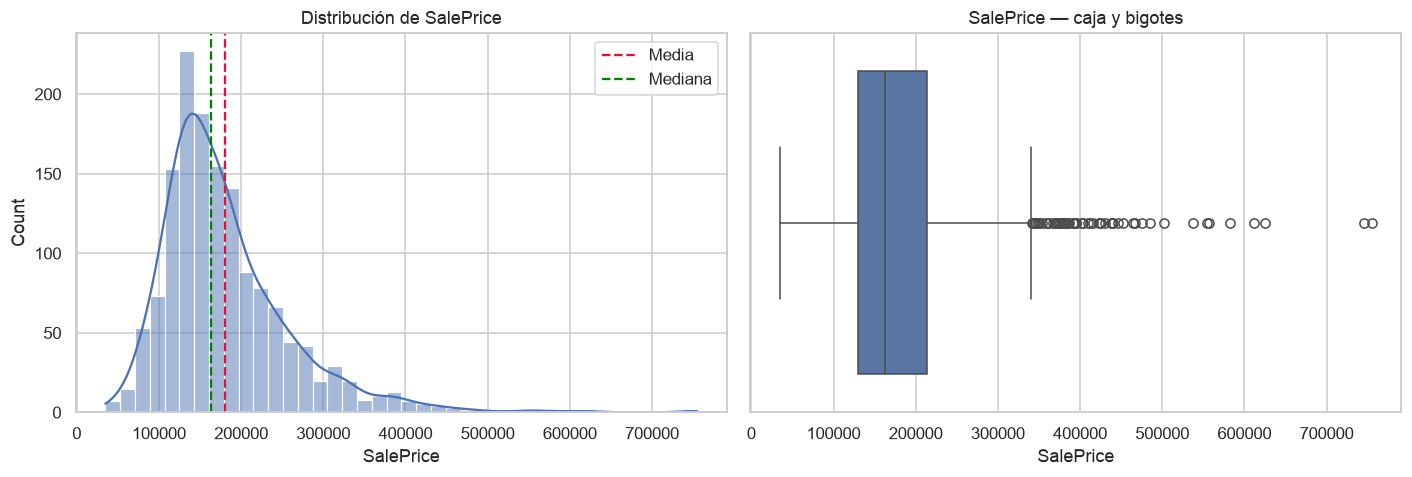

In [11]:
figura, ejes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(datos_crudos['SalePrice'], bins=40, kde=True, ax=ejes[0])
ejes[0].axvline(datos_crudos['SalePrice'].mean(), color='crimson', linestyle='--', label='Media')
ejes[0].axvline(datos_crudos['SalePrice'].median(), color='green', linestyle='--', label='Mediana')
ejes[0].set_title('Distribución de SalePrice')
ejes[0].legend()

sns.boxplot(x=datos_crudos['SalePrice'], ax=ejes[1])
ejes[1].set_title('SalePrice — caja y bigotes')

plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'fig2b_saleprice_distribucion.png'), dpi=150)
plt.show()


### Lo que se observa

**Valores faltantes.** El `count` de varias columnas es menor a 1.460 (`LotFrontage`,
`MasVnrArea`, `GarageYrBlt`...), lo que confirma valores nulos ya detectados en la sección 0.5.
El tratamiento detallado se hace en el Punto 2 (más abajo).

**Varianza casi nula.** Cinco variables numéricas tienen el 95% o más de sus valores
concentrados en uno solo: `PoolArea` (99,5%), `3SsnPorch` (98,4%), `LowQualFinSF` (98,2%),
`MiscVal` (96,4%) y `KitchenAbvGr` (95,3%). En la práctica, casi todas las viviendas comparten
ese mismo valor (típicamente 0, salvo `KitchenAbvGr` que vale 1 en casi todos los casos), así
que estas columnas aportan muy poca capacidad para discriminar precios. Son candidatas a
eliminar, y se retoman en la síntesis del Punto 5.

**Asimetría.** `SalePrice` tiene una asimetría de **1,88**: la media (180.921) está claramente
por encima de la mediana (163.000), signo de una cola larga hacia precios altos — hay pocas
viviendas muy caras que estiran el promedio. El caso más extremo del dataset es `MiscVal`
(asimetría 24,5), seguido de `PoolArea` (14,8) y `LotArea` (12,2): son justamente las mismas
variables de varianza casi nula, lo que confirma que su distribución no es "poco variable" en
sentido inocuo, sino que tiene un puñado de valores atípicos muy alejados de una masa
concentrada en 0.

Esta asimetría de `SalePrice` es la razón directa por la que, en el problema de clasificación
(más adelante), el grupo de precio alto (grupo3, ≥ 500.001) va a tener muy pocas observaciones:
la cola larga a la derecha significa pocas viviendas caras en términos absolutos.

**¿Podríamos eliminar algunas variables?** Sí — las de varianza casi nula listadas arriba son
las primeras candidatas, porque casi no varían entre observaciones y por lo tanto casi no
ayudan a un modelo a separar precios distintos.


---
## 3 · Variables categóricas: categorías y frecuencia

*Criterio 1. Corresponde a la figura 2 del enunciado.*


In [12]:
cardinalidad = datos_crudos[columnas_categoricas].nunique().sort_values(ascending=False)
cardinalidad.head(10).to_frame('categorias_distintas')


,categorias_distintas
Neighborhood,25
Exterior2nd,16
Exterior1st,15
SaleType,9
Condition1,9
Condition2,8
HouseStyle,8
RoofMatl,8
Functional,7
BsmtFinType2,6


In [13]:
for columna in columnas_categoricas:
    print(f"--- {columna} ({datos_crudos[columna].nunique(dropna=True)} categorías) ---")
    print(datos_crudos[columna].value_counts(dropna=False))
    print()


--- MSZoning (5 categorías) ---
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

--- Street (2 categorías) ---
Street
Pave    1454
Grvl       6
Name: count, dtype: int64

--- Alley (2 categorías) ---
Alley
NaN     1369
Grvl      50
Pave      41
Name: count, dtype: int64

--- LotShape (4 categorías) ---
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

--- LandContour (4 categorías) ---
LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

--- Utilities (2 categorías) ---
Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

--- LotConfig (5 categorías) ---
LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64

--- LandSlope (3 categorías) ---
LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64

--- Neighborhood (25 categorías) ---
Neighborhood
NAmes      225
CollgC

In [14]:
# Igual que con las numéricas: categóricas con una categoría dominante (>=95%)
varianza_casi_nula_cat = []
for columna in columnas_categoricas:
    conteo = datos_crudos[columna].value_counts(normalize=True, dropna=False)
    proporcion_dominante = conteo.iloc[0]
    if proporcion_dominante >= 0.95:
        varianza_casi_nula_cat.append(
            (columna, conteo.index[0], round(proporcion_dominante * 100, 1))
        )

pd.DataFrame(varianza_casi_nula_cat, columns=['variable', 'categoria_dominante', 'pct']) \
    .sort_values('pct', ascending=False)


,variable,categoria_dominante,pct
1,Utilities,AllPub,99.9
0,Street,Pave,99.6
5,PoolQC,NaN,99.5
2,Condition2,Norm,99.0
3,RoofMatl,CompShg,98.2
4,Heating,GasA,97.8
6,MiscFeature,NaN,96.3


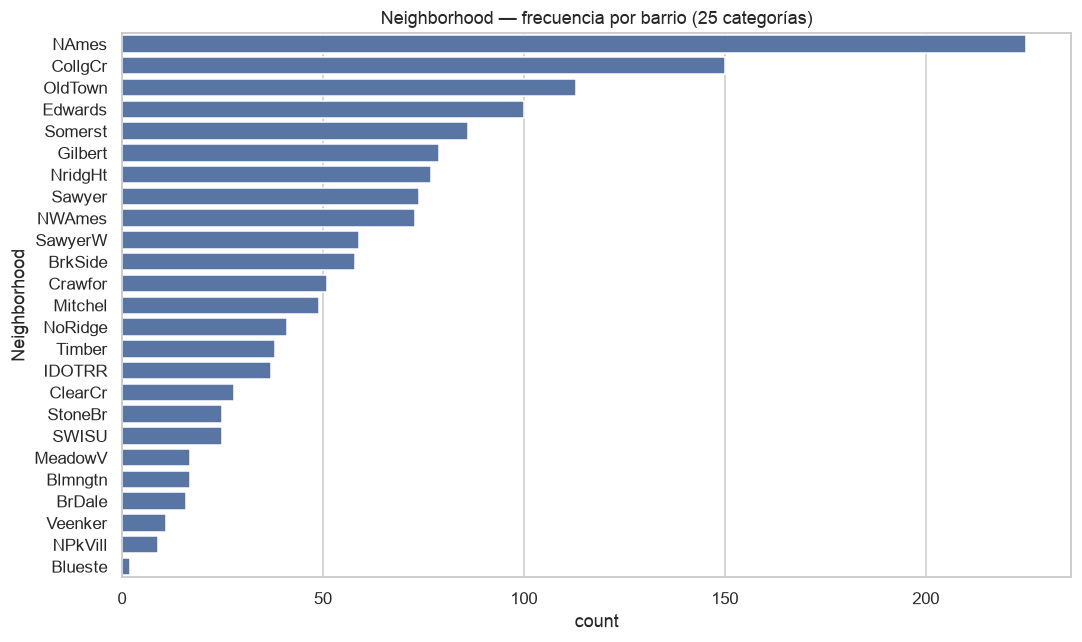

In [15]:
figura, eje = plt.subplots(figsize=(10, 6))
orden = datos_crudos['Neighborhood'].value_counts().index
sns.countplot(data=datos_crudos, y='Neighborhood', order=orden, ax=eje)
eje.set_title('Neighborhood — frecuencia por barrio (25 categorías)')
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'fig2c_neighborhood.png'), dpi=150)
plt.show()


### Lo que se observa

**Cardinalidad.** La mayoría de las categóricas tiene pocos niveles (2 a 8), pero unas pocas
concentran muchas categorías: `Neighborhood` con **25 barrios distintos**, `Exterior2nd` con 16
y `Exterior1st` con 15. `Neighborhood` va desde `NAmes` con 225 viviendas hasta `Blueste` con
solo **2** — un desbalance de más de 100 a 1 entre el barrio más y menos frecuente. Esto importa
para la Parte 2: al codificar con one-hot antes de SVM o la red neuronal, `Neighborhood` por sí
sola generaría 24 columnas nuevas, y varias de ellas (las de los barrios con 2-9 viviendas)
tendrán casi todo el bloque en 0.

**Variables con varianza casi nula.** Siete categóricas tienen una categoría que concentra el
95% o más de las observaciones: `Utilities` (99,9% `AllPub`), `Street` (99,6% `Pave`),
`Condition2` (99,0% `Norm`), `RoofMatl` (98,2% `CompShg`), `Heating` (97,8% `GasA`), y
`PoolQC`/`MiscFeature`, donde el valor dominante es directamente la ausencia del dato (95-99,5%
nulos). `Utilities` es el caso más extremo: 1.459 de 1.460 viviendas comparten la categoría
`AllPub`, así que prácticamente no puede ayudar a ningún modelo a diferenciar precios —
es candidata directa a eliminar.

**Variables con buena señal aparente.** En contraste, `MSZoning` (`RL` 1.151, `RM` 218, `FV` 65,
`RH` 16, `C (all)` 10), `SaleCondition` (`Normal` 1.198, `Partial` 125, `Abnorml` 101...) y
`CentralAir` (`Y` 1.365 / `N` 95) reparten sus observaciones de forma menos extrema y son más
prometedoras como predictoras: por ejemplo, es razonable esperar que `SaleCondition = Partial`
(venta de una vivienda recién construida) se asocie a precios distintos que `Abnorml` (venta
forzada, embargo, etc.).

**¿Podríamos eliminar algunas variables?** Sí, las mismas siete de varianza casi nula listadas
arriba. Se documentan aquí y se consolidan, junto con las numéricas de la sección 2, en la
síntesis del Punto 5.


---
## 4 · Matriz de correlaciones entre variables numéricas

*Criterio 1. Corresponde a la figura 3 del enunciado.*


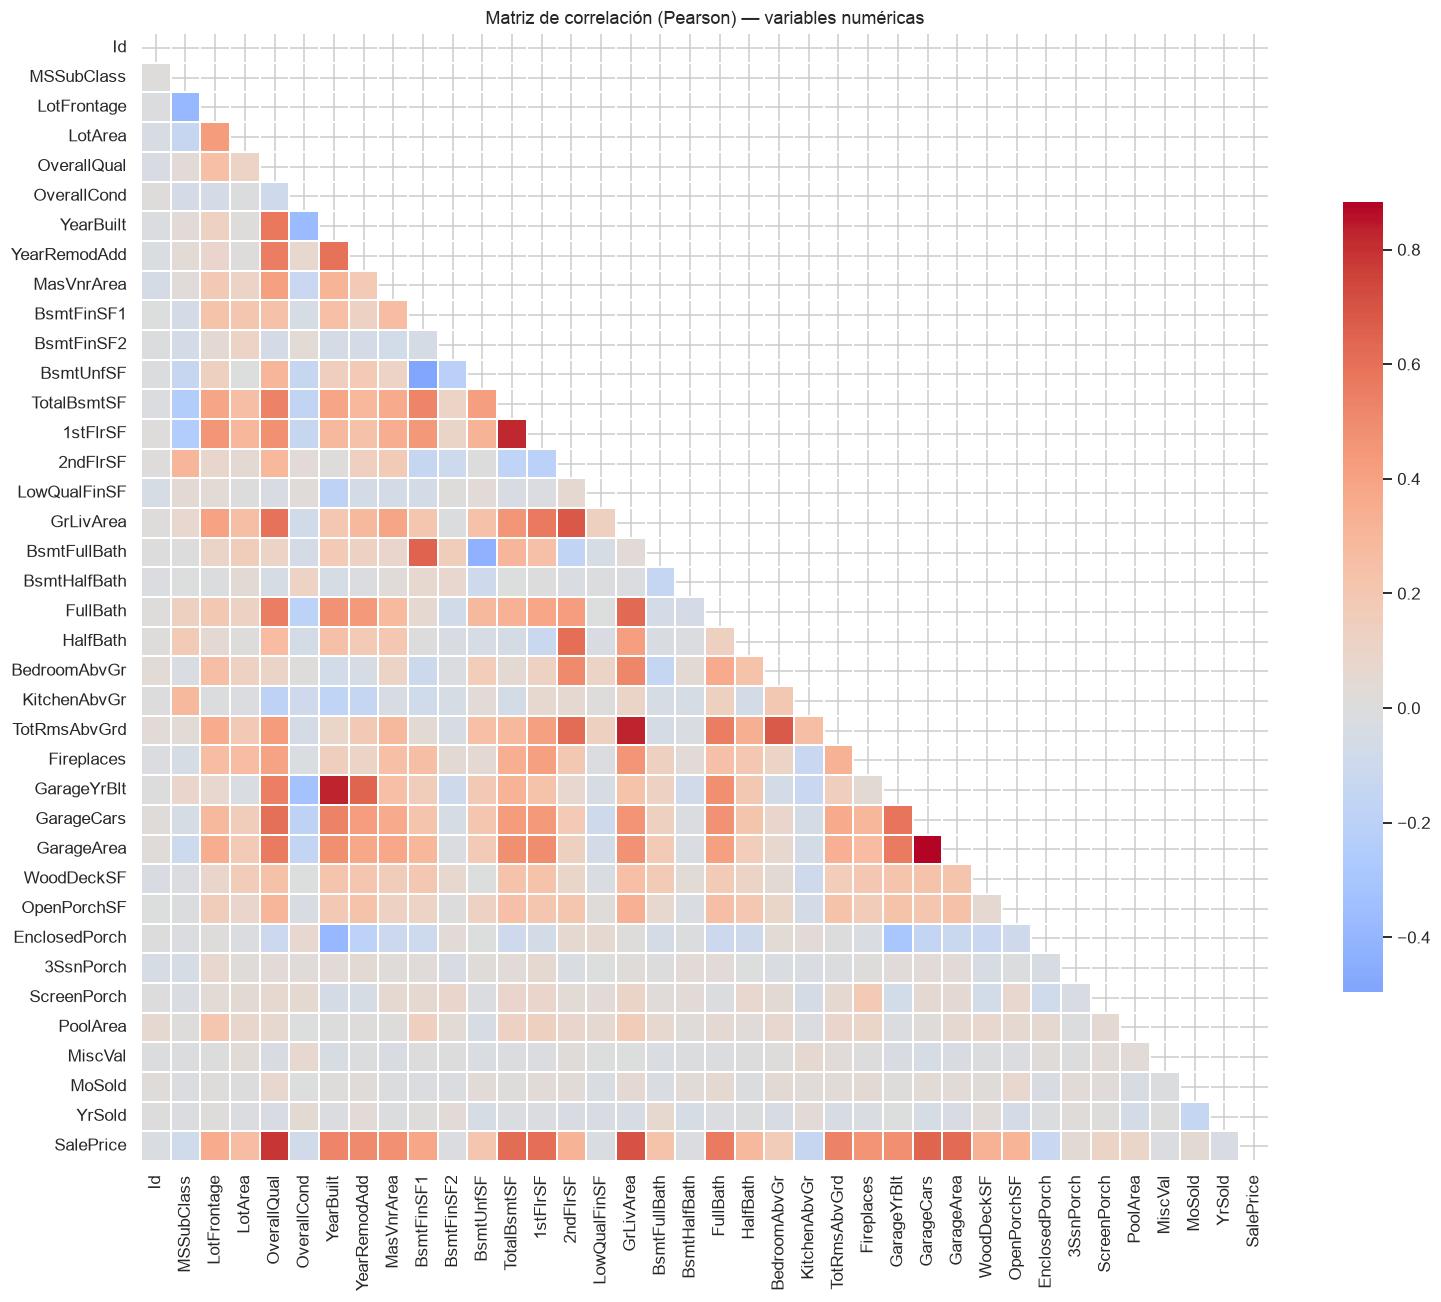

In [16]:
matriz_correlacion = datos_crudos[columnas_numericas].corr(method='pearson')

plt.figure(figsize=(15, 12))
mascara = np.triu(np.ones_like(matriz_correlacion, dtype=bool))
sns.heatmap(matriz_correlacion, mask=mascara, cmap='coolwarm', center=0,
            square=True, linewidths=0.3, cbar_kws={'shrink': 0.7})
plt.title('Matriz de correlación (Pearson) — variables numéricas')
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'fig3_matriz_correlacion.png'), dpi=150)
plt.show()


In [17]:
correlacion_objetivo = (matriz_correlacion['SalePrice']
                         .drop('SalePrice')
                         .sort_values(ascending=False))

print("Top 10 correlación positiva con SalePrice:")
print(correlacion_objetivo.head(10).round(3))
print("\nÚltimas 5 (correlación más débil/negativa):")
print(correlacion_objetivo.tail(5).round(3))


Top 10 correlación positiva con SalePrice:
OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507
Name: SalePrice, dtype: float64

Últimas 5 (correlación más débil/negativa):
YrSold          -0.029
OverallCond     -0.078
MSSubClass      -0.084
EnclosedPorch   -0.129
KitchenAbvGr    -0.136
Name: SalePrice, dtype: float64


In [18]:
# Pares de predictoras con correlación >= 0.75 entre sí: candidatos a multicolinealidad
umbral = 0.75
columnas_sin_objetivo = matriz_correlacion.columns.drop('SalePrice')
pares_redundantes = []

for i, var1 in enumerate(columnas_sin_objetivo):
    for var2 in columnas_sin_objetivo[i + 1:]:
        correlacion = matriz_correlacion.loc[var1, var2]
        if abs(correlacion) >= umbral:
            pares_redundantes.append((
                var1, var2, round(correlacion, 3),
                round(correlacion_objetivo[var1], 3),
                round(correlacion_objetivo[var2], 3),
            ))

tabla_redundantes = pd.DataFrame(
    pares_redundantes,
    columns=['variable_1', 'variable_2', 'corr_entre_si', 'corr_var1_SalePrice', 'corr_var2_SalePrice']
).sort_values('corr_entre_si', ascending=False)

tabla_redundantes


,variable_1,variable_2,corr_entre_si,corr_var1_SalePrice,corr_var2_SalePrice
3,GarageCars,GarageArea,0.882,0.640,0.623
0,YearBuilt,GarageYrBlt,0.826,0.523,0.486
2,GrLivArea,TotRmsAbvGrd,0.825,0.709,0.534
1,TotalBsmtSF,1stFlrSF,0.820,0.614,0.606


### Lo que se observa

**Correlación con `SalePrice`.** Las predictoras más fuertes son `OverallQual` (0,791),
`GrLivArea` (0,709), `GarageCars` (0,640), `GarageArea` (0,623), `TotalBsmtSF` (0,614),
`1stFlrSF` (0,606), `FullBath` (0,561), `TotRmsAbvGrd` (0,534), `YearBuilt` (0,523) y
`YearRemodAdd` (0,507). Tiene sentido de dominio: calidad general de acabados, superficie
habitable y tamaño del garaje son justamente los factores que más intuitivamente mueven el
precio de una vivienda. En el extremo opuesto, `YrSold` (−0,029), `OverallCond` (−0,078) y
`MSSubClass` (−0,084) prácticamente no correlacionan linealmente con el precio — aunque, como se
anotó en la sección 1, `MSSubClass` es una categórica codificada como número, así que una
correlación de Pearson cercana a 0 aquí no es evidencia de que la variable no sirva, sino de que
la relación (si existe) no es lineal.

**Multicolinealidad (pares redundantes, corr. ≥ 0,75).** Aparecen cuatro pares que miden
esencialmente lo mismo:

| Par | Corr. entre sí | ¿Cuál se conserva? |
|---|---|---|
| `GarageCars` ↔ `GarageArea` | 0,882 | `GarageCars` (corr. 0,640 vs. 0,623 con `SalePrice`) |
| `YearBuilt` ↔ `GarageYrBlt` | 0,826 | `YearBuilt` (0,523 vs. 0,486) |
| `GrLivArea` ↔ `TotRmsAbvGrd` | 0,825 | `GrLivArea` (0,709 vs. 0,534) |
| `TotalBsmtSF` ↔ `1stFlrSF` | 0,820 | `TotalBsmtSF` (0,614 vs. 0,606) |

El criterio de decisión es directo: de cada par se conserva la variable que correlaciona más
fuerte con `SalePrice` y se descarta la otra. Tiene sentido físico en los cuatro casos:
`GarageCars` (capacidad en autos) resume mejor la utilidad del garaje que su área en pies
cuadrados; el sótano suele compartir huella con la planta baja (`TotalBsmtSF` vs. `1stFlrSF`);
más superficie habitable implica más habitaciones (`GrLivArea` vs. `TotRmsAbvGrd`); y el garaje
casi siempre se construye junto con la casa (`YearBuilt` vs. `GarageYrBlt`).

**Un matiz importante: esto no mejora la capacidad predictiva de árboles ni de random forest.**
La multicolinealidad no perjudica su desempeño — solo *reparte* la importancia entre las
variables correlacionadas, lo que distorsiona la interpretación del *feature importance* pero no
la predicción en sí. El beneficio real de eliminar estas columnas es de **interpretabilidad** y
**coste computacional**. Donde sí importaría eliminarlas por motivos de desempeño es en un
modelo lineal, en SVM o en la red neuronal de la Parte 2, que sí son sensibles a predictoras
redundantes entre sí.

**Limitación del método.** `corr()` con Pearson mide relaciones lineales. `OverallQual` es
ordinal, no continua, así que Spearman sería técnicamente más apropiado para ella; se usa
Pearson aquí para replicar la figura 3 del enunciado, dejando esta limitación documentada.


---
## 5 · Síntesis del Punto 1: columnas candidatas a eliminar

*Criterio 1. Punto de cierre del análisis descriptivo.*

Antes de pasar al tratamiento de valores faltantes (Punto 2), consolidamos aquí todas las
columnas identificadas como candidatas a eliminar a lo largo de las secciones 1 a 4, con su
motivo:

| Columna | Motivo | Sección |
|---|---|---|
| `Id` | Identificador de fila, sin valor predictivo | 1 |
| `PoolArea`, `3SsnPorch`, `LowQualFinSF`, `MiscVal`, `KitchenAbvGr` | Varianza casi nula (≥95% del mismo valor) | 2 |
| `Utilities`, `Street`, `Condition2`, `RoofMatl`, `Heating` | Varianza casi nula (≥95% de una sola categoría) | 3 |
| `GarageArea` | Redundante con `GarageCars` (corr. 0,882) | 4 |
| `GarageYrBlt` | Redundante con `YearBuilt` (corr. 0,826) | 4 |
| `TotRmsAbvGrd` | Redundante con `GrLivArea` (corr. 0,825) | 4 |
| `1stFlrSF` | Redundante con `TotalBsmtSF` (corr. 0,820) | 4 |

`PoolQC` y `MiscFeature` **no** se incluyen todavía en esta lista, aunque también tienen
varianza casi nula: su "categoría dominante" es en realidad la ausencia del dato (99,5% y 96,3%
de nulos respectivamente), así que su tratamiento se decide junto con el resto de valores
faltantes en el Punto 2, no aquí.

Esta lista se aplica de forma explícita más adelante, después de resolver el tratamiento de
missing — varias de las columnas con más nulos (`Garage*`, `Bsmt*`) requieren decidir primero
si el NA significa "no tiene garaje/sótano" antes de decidir si se eliminan o se imputan.


---
## 6 · Tratamiento de valores faltantes

*Criterio 2. Corresponde a la figura 4 del enunciado.*


In [19]:
nulos = datos_crudos.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)

tabla_nulos = pd.DataFrame({
    'nulos': nulos,
    'pct_nulos': (nulos / len(datos_crudos) * 100).round(1),
})
tabla_nulos


,nulos,pct_nulos
PoolQC,1453,99.5
MiscFeature,1406,96.3
Alley,1369,93.8
Fence,1179,80.8
MasVnrType,872,59.7
FireplaceQu,690,47.3
LotFrontage,259,17.7
GarageType,81,5.5
GarageYrBlt,81,5.5
GarageFinish,81,5.5


### 6.1 · ¿NA estructural o NA real?

19 columnas tienen valores nulos, con porcentajes que van del 99,5% (`PoolQC`) al 0,1%
(`Electrical`, una sola fila). Antes de decidir cómo tratarlos hay que resolver una pregunta
previa: en un dataset de vivienda, un `NA` en una columna de calidad de garaje o de sótano no
necesariamente significa "dato perdido" — puede significar **"esta vivienda no tiene garaje"**.
El diccionario de datos original de Kaggle confirma esta lectura para varias columnas.

La forma de verificarlo es cruzar cada columna categórica con nulos contra su variable numérica
asociada: si el `NA` coincide siempre con que esa característica vale 0 (sin garaje, sin
chimeneas, sin sótano...), es NA estructural, no un dato perdido.


In [20]:
verificacion_estructural = []
pares = [
    ('PoolQC', 'PoolArea'), ('FireplaceQu', 'Fireplaces'),
    ('GarageType', 'GarageCars'), ('GarageFinish', 'GarageCars'),
    ('GarageQual', 'GarageCars'), ('GarageCond', 'GarageCars'),
    ('BsmtQual', 'TotalBsmtSF'), ('BsmtCond', 'TotalBsmtSF'),
    ('BsmtExposure', 'TotalBsmtSF'), ('BsmtFinType1', 'TotalBsmtSF'),
    ('BsmtFinType2', 'TotalBsmtSF'),
]

for columna_cat, columna_num in pares:
    mascara_na = datos_crudos[columna_cat].isnull()
    coinciden = (datos_crudos.loc[mascara_na, columna_num] == 0).sum()
    verificacion_estructural.append((columna_cat, mascara_na.sum(), coinciden))

pd.DataFrame(verificacion_estructural,
             columns=['columna', 'total_NA', 'NA_donde_variable_relacionada_es_0'])


,columna,total_NA,NA_donde_variable_relacionada_es_0
0,PoolQC,1453,1453
1,FireplaceQu,690,690
2,GarageType,81,81
3,GarageFinish,81,81
4,GarageQual,81,81
5,GarageCond,81,81
6,BsmtQual,37,37
7,BsmtCond,37,37
8,BsmtExposure,38,37
9,BsmtFinType1,37,37


El cruce confirma que **la inmensa mayoría de los NA son estructurales**: en `PoolQC`,
`FireplaceQu` y las cuatro columnas de garaje, el 100% de los nulos coincide con que la
vivienda no tiene esa característica (`PoolArea = 0`, `Fireplaces = 0`, `GarageCars = 0`). Lo
mismo pasa con `BsmtQual`, `BsmtCond` y `BsmtFinType1` (37 de 37).

**Pero `BsmtExposure` y `BsmtFinType2` no cuadran del todo: tienen 38 nulos, y solo 37 coinciden
con `TotalBsmtSF = 0`.** Hay una fila en cada caso donde la vivienda sí tiene sótano (con el
resto de columnas de sótano completas) pero falta específicamente ese dato — ahí sí hay un
valor genuinamente perdido, no estructural. También `GarageYrBlt` tiene 81 nulos que coinciden
exactamente con los de `GarageType`, así que es igual de estructural que el resto de columnas
de garaje — aunque, como se decidió en la sección 5, esa columna ya se elimina por
redundancia con `YearBuilt`, así que su tratamiento de missing queda resuelto de antemano.


### 6.2 · Los dos casos de sótano con dato real perdido


In [21]:
fila_bsmtfin2 = datos_crudos[datos_crudos['BsmtFinType2'].isnull() & datos_crudos['BsmtQual'].notnull()]
fila_exposure = datos_crudos[datos_crudos['BsmtExposure'].isnull() & datos_crudos['BsmtQual'].notnull()]

columnas_bsmt = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'TotalBsmtSF']
pd.concat([fila_bsmtfin2, fila_exposure])[columnas_bsmt]


,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,TotalBsmtSF
332,Gd,TA,No,GLQ,NaN,3206
948,Gd,TA,NaN,Unf,Unf,936


Ambas viviendas tienen sótanos grandes (3.206 y 936 pies²) con el resto de columnas de sótano
completas — no son casas sin sótano, son dos datos puntuales que faltan. Con solo 2 filas
afectadas (0,14% del dataset), la decisión razonable es **imputar con la moda de cada columna**,
en vez de eliminar las filas o dejar el NA: `BsmtFinType2` con `Unf` (la categoría más frecuente,
"sin terminar", que además es coherente con tener ya un `BsmtFinType1` completo) y
`BsmtExposure` con `No` (sin exposición al exterior, la categoría dominante).


### 6.3 · `MasVnrType` y `MasVnrArea`: tres patrones distintos bajo el mismo NA

`MasVnrType` (tipo de revestimiento de mampostería) tiene 872 nulos — el 59,7% del dataset, el
segundo porcentaje más alto después de `PoolQC` y `MiscFeature`. A primera vista parece un caso
extremo de dato perdido, pero al cruzarlo con `MasVnrArea` (el área de ese revestimiento)
aparecen tres grupos con tratamientos distintos.


In [22]:
sin_veneer = datos_crudos[datos_crudos['MasVnrType'].isnull() & (datos_crudos['MasVnrArea'] == 0)]
tipo_desconocido = datos_crudos[datos_crudos['MasVnrType'].isnull() &
                                 datos_crudos['MasVnrArea'].notnull() & (datos_crudos['MasVnrArea'] > 0)]
ambos_desconocidos = datos_crudos[datos_crudos['MasVnrType'].isnull() & datos_crudos['MasVnrArea'].isnull()]

print(f"Grupo A · sin revestimiento (MasVnrArea = 0): {len(sin_veneer)} filas")
print(f"Grupo B · tiene revestimiento pero el tipo es desconocido (MasVnrArea > 0): {len(tipo_desconocido)} filas")
print(f"Grupo C · no se sabe ni el tipo ni el área: {len(ambos_desconocidos)} filas")
print()
tipo_desconocido[['MasVnrType', 'MasVnrArea']]


Grupo A · sin revestimiento (MasVnrArea = 0): 859 filas
Grupo B · tiene revestimiento pero el tipo es desconocido (MasVnrArea > 0): 5 filas
Grupo C · no se sabe ni el tipo ni el área: 8 filas



,MasVnrType,MasVnrArea
624,NaN,288.0
773,NaN,1.0
1230,NaN,1.0
1300,NaN,344.0
1334,NaN,312.0


- **Grupo A (859 filas, 58,8%):** `MasVnrArea = 0` — la vivienda simplemente no tiene
  revestimiento de mampostería. Es NA estructural: se imputa con la categoría `None`.
- **Grupo B (5 filas):** el área es conocida y mayor a 0 (entre 1 y 344 pies²), así que la
  vivienda sí tiene revestimiento, pero el tipo específico no quedó registrado. Aquí sí es un
  dato perdido real. Se imputa con la moda del tipo *entre las viviendas que sí tienen
  revestimiento* (`BrkFace`), no con la moda global (que sería `None` y sería contradictorio
  con tener un área positiva).
- **Grupo C (8 filas, 0,5%):** ni el tipo ni el área se conocen. Al ser un porcentaje mínimo del
  dataset y no tener ninguna pista adicional, se trata igual que el grupo A por ser el patrón
  ampliamente dominante (`None` / 0) — una decisión razonable dado que el 98,5% de los casos con
  `MasVnrType` nulo caen en el grupo A.


### 6.4 · `LotFrontage`: imputación por barrio, no global


In [23]:
print("Asimetría de LotFrontage:", round(datos_crudos['LotFrontage'].skew(), 2))
print("Media:", round(datos_crudos['LotFrontage'].mean(), 1), "| Mediana:", datos_crudos['LotFrontage'].median())
print("Correlación con LotArea:", round(datos_crudos['LotFrontage'].corr(datos_crudos['LotArea']), 3))
print()
print("Mediana de LotFrontage por barrio (extremos):")
medianas_barrio = datos_crudos.groupby('Neighborhood')['LotFrontage'].median().sort_values()
print(pd.concat([medianas_barrio.head(3), medianas_barrio.tail(3)]))


Asimetría de LotFrontage: 2.16
Media: 70.0 | Mediana: 69.0
Correlación con LotArea: 0.426

Mediana de LotFrontage por barrio (extremos):
Neighborhood
BrDale     21.0
MeadowV    21.0
Blueste    24.0
Timber     85.0
NridgHt    88.5
NoRidge    91.0
Name: LotFrontage, dtype: float64


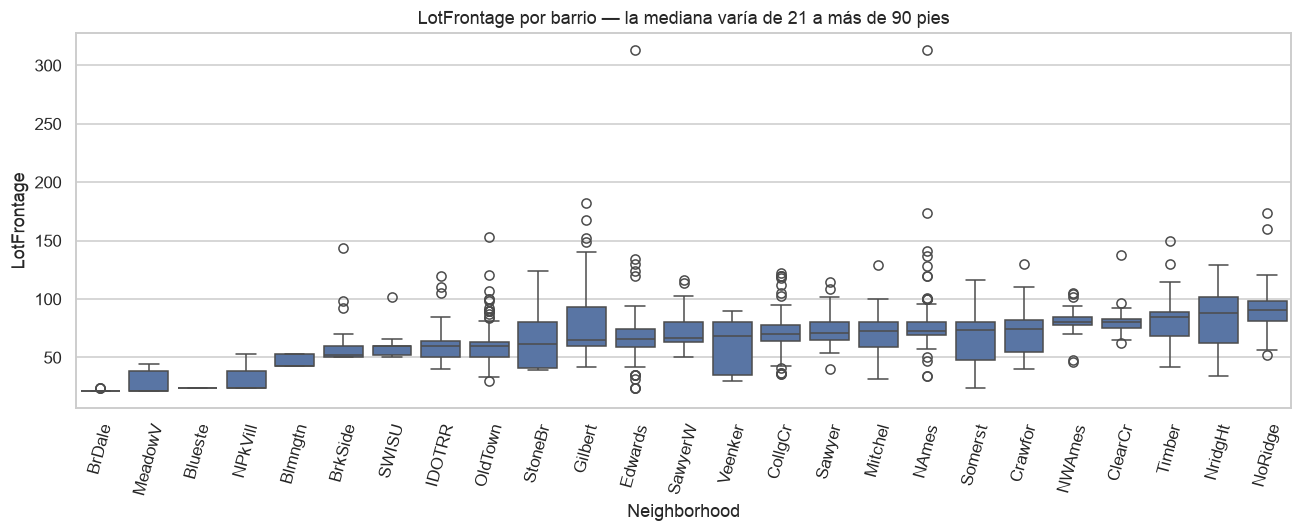

In [24]:
figura, eje = plt.subplots(figsize=(12, 5))
orden_barrios = datos_crudos.groupby('Neighborhood')['LotFrontage'].median().sort_values().index
sns.boxplot(data=datos_crudos, x='Neighborhood', y='LotFrontage', order=orden_barrios, ax=eje)
eje.set_title('LotFrontage por barrio — la mediana varía de 21 a más de 90 pies')
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'fig4_lotfrontage_por_barrio.png'), dpi=150)
plt.show()


`LotFrontage` (pies de frente de la propiedad sobre la calle) es el caso más importante de dato
realmente perdido: 259 nulos (17,7%), sin ningún patrón estructural asociado — cualquier
vivienda puede tener este dato faltante, sin importar si tiene garaje, sótano, etc.

Dos motivos descartan una imputación simple con la media o la mediana global:

1. **Asimetría de 2,16**: la media (70,0) está por encima de la mediana (69,0) por la cola de
   lotes muy anchos, así que ya de entrada la mediana es preferible a la media.
2. **Varía mucho según el barrio**: la mediana por barrio va de 21 pies en `BrDale`/`MeadowV`
   hasta más de 90 en los barrios con lotes más amplios. Usar una única mediana global (69)
   para imputar una vivienda en `BrDale` sobreestimaría su frente en más del 200%.

Por eso la imputación se hace con **la mediana de `LotFrontage` dentro de cada `Neighborhood`**,
y solo se recurre a la mediana global en el caso excepcional de que un barrio completo no tenga
ningún valor observado de `LotFrontage` (no ocurre en este dataset, pero se deja como salvaguarda
en el código de la sección 7).


### 6.5 · `Electrical`: una sola fila


In [25]:
datos_crudos[datos_crudos['Electrical'].isnull()][['Electrical', 'YearBuilt', 'Utilities', 'SalePrice']]


,Electrical,YearBuilt,Utilities,SalePrice
1379,NaN,2006,AllPub,167500


Una única vivienda (0,07% del dataset) no tiene registrado el sistema eléctrico. La categoría
dominante, `SBrkr` (disyuntores estándar), representa el 91,4% de las observaciones. Con un solo
caso y una categoría tan dominante, **imputar con la moda** es preferible a eliminar la fila:
el efecto sobre el resto del análisis es prácticamente nulo en cualquiera de las dos opciones,
pero imputar conserva el tamaño de muestra completo (1.460 filas) para los pasos siguientes.


### 6.6 · Revisando el criterio de varianza casi nula después de imputar

En la síntesis del Punto 1 (sección 5) se dejaron pendientes `PoolQC` y `MiscFeature`
precisamente para decidirlas aquí, una vez resuelto el tratamiento de missing. La pregunta es:
después de imputar el NA estructural con una categoría explícita (`Sin_Piscina`, `Ninguno`,
etc.), ¿esa categoría vuelve a superar el umbral de 95% que se usó en el Punto 1 para descartar
columnas de varianza casi nula?


In [26]:
columnas_estructurales = {
    'PoolQC': 'Sin_Piscina', 'MiscFeature': 'Ninguno',
    'Alley': 'Sin_Acceso', 'Fence': 'Sin_Cerca', 'FireplaceQu': 'Sin_Chimenea',
}

revision_umbral = []
for columna, categoria in columnas_estructurales.items():
    pct_categoria = datos_crudos[columna].isnull().mean() * 100
    revision_umbral.append((columna, categoria, round(pct_categoria, 1), pct_categoria >= 95))

pd.DataFrame(revision_umbral, columns=['columna', 'categoria_imputada', 'pct_tras_imputar', 'supera_95pct'])


,columna,categoria_imputada,pct_tras_imputar,supera_95pct
0,PoolQC,Sin_Piscina,99.5,True
1,MiscFeature,Ninguno,96.3,True
2,Alley,Sin_Acceso,93.8,False
3,Fence,Sin_Cerca,80.8,False
4,FireplaceQu,Sin_Chimenea,47.3,False


Con el mismo umbral del 95% aplicado en el Punto 1: **`PoolQC` (99,5%) y `MiscFeature` (96,3%)
lo superan** y se suman a la lista de columnas a eliminar, exactamente por la misma razón que
ya llevó a eliminar `PoolArea` y `MiscVal` — miden lo mismo (si la vivienda tiene piscina /
tiene alguna característica misceláneas) y en más del 95% de los casos la respuesta es la misma.
`Alley` (93,8%) queda justo por debajo del umbral formal: se conserva, aunque se señala como
borderline. `Fence` (80,8%) y `FireplaceQu` (47,3%) tienen suficiente variedad en sus categorías
no nulas como para aportar información real y se conservan sin duda.


---
## 7 · Dataset preparado

*Criterio 2. Aplica en conjunto las decisiones del Punto 1 (sección 5) y del Punto 2
(secciones 6.1 a 6.6), y guarda el resultado para reutilizarlo en el resto del laboratorio.*


In [27]:
datos = datos_crudos.copy()

# --- 1. Columnas a eliminar (Punto 1 sección 5 + PoolQC y MiscFeature de la sección 6.6) ---
columnas_a_eliminar = [
    'Id',
    'PoolArea', '3SsnPorch', 'LowQualFinSF', 'MiscVal', 'KitchenAbvGr',
    'Utilities', 'Street', 'Condition2', 'RoofMatl', 'Heating',
    'GarageArea', 'GarageYrBlt', 'TotRmsAbvGrd', '1stFlrSF',
    'PoolQC', 'MiscFeature',
]
datos = datos.drop(columns=columnas_a_eliminar)

# --- 2. NA estructural: se imputa con una categoría explícita, no con la moda ---
columnas_estructurales = {
    'Alley': 'Sin_Acceso', 'Fence': 'Sin_Cerca', 'FireplaceQu': 'Sin_Chimenea',
    'GarageType': 'Sin_Garaje', 'GarageFinish': 'Sin_Garaje',
    'GarageQual': 'Sin_Garaje', 'GarageCond': 'Sin_Garaje',
    'BsmtQual': 'Sin_Sotano', 'BsmtCond': 'Sin_Sotano', 'BsmtFinType1': 'Sin_Sotano',
}
for columna, categoria in columnas_estructurales.items():
    datos[columna] = datos[columna].fillna(categoria)

# --- 3. Los dos casos reales de sótano (sección 6.2): imputar con la moda ---
datos['BsmtFinType2'] = datos['BsmtFinType2'].fillna(datos['BsmtFinType2'].mode()[0])
datos['BsmtExposure'] = datos['BsmtExposure'].fillna(datos['BsmtExposure'].mode()[0])
# Las filas restantes de BsmtExposure/BsmtFinType2 (las estructurales) también quedaron sin
# sótano: se homologan a 'Sin_Sotano' para que las cuatro columnas de sótano usen la misma
# categoría cuando la vivienda no tiene sótano.
mascara_sin_sotano = datos['BsmtQual'] == 'Sin_Sotano'
datos.loc[mascara_sin_sotano, 'BsmtExposure'] = 'Sin_Sotano'
datos.loc[mascara_sin_sotano, 'BsmtFinType2'] = 'Sin_Sotano'

# --- 4. MasVnrType / MasVnrArea: los tres grupos de la sección 6.3 ---
moda_tipo_con_veneer = datos_crudos.loc[datos_crudos['MasVnrArea'] > 0, 'MasVnrType'].mode()[0]
mascara_tipo_desconocido = datos['MasVnrType'].isnull() & (datos['MasVnrArea'] > 0)
datos.loc[mascara_tipo_desconocido, 'MasVnrType'] = moda_tipo_con_veneer
datos['MasVnrType'] = datos['MasVnrType'].fillna('None')      # grupos A y C
datos['MasVnrArea'] = datos['MasVnrArea'].fillna(0)           # grupos A y C

# --- 5. LotFrontage: mediana por barrio (sección 6.4) ---
datos['LotFrontage'] = datos.groupby('Neighborhood')['LotFrontage'] \
    .transform(lambda serie: serie.fillna(serie.median()))
datos['LotFrontage'] = datos['LotFrontage'].fillna(datos['LotFrontage'].median())  # salvaguarda

# --- 6. Electrical: moda (sección 6.5) ---
datos['Electrical'] = datos['Electrical'].fillna(datos['Electrical'].mode()[0])

print("Columnas eliminadas:", len(columnas_a_eliminar))
print("Filas:", datos.shape[0], "| Columnas:", datos.shape[1])


Columnas eliminadas: 17
Filas: 1460 | Columnas: 64


In [28]:
# Comprobación: no debe quedar ningún nulo
nulos_restantes = datos.isnull().sum()
nulos_restantes = nulos_restantes[nulos_restantes > 0]

if len(nulos_restantes) == 0:
    print("Sin valores nulos. Dataset listo.")
else:
    print("Quedan nulos sin tratar:")
    print(nulos_restantes)

datos.to_csv(os.path.join(CARPETA_DATOS, 'datos_preparados.csv'), index=False)
print("\nGuardado en:", os.path.join(CARPETA_DATOS, 'datos_preparados.csv'))


Sin valores nulos. Dataset listo.

Guardado en: /Users/christian_cortes/Desktop/especializacion_christian/actividad_casas/datos/datos_preparados.csv


El dataset queda en **1.460 filas y 64 columnas** (81 originales menos las 17 eliminadas: las 15
de la síntesis del Punto 1 más `PoolQC` y `MiscFeature` decididas en la sección 6.6), sin
ningún valor nulo. `datos_preparados.csv` es el punto de partida para el resto del
laboratorio: la Parte 1 (árboles y random forest, regresión y clasificación) y toda la
Parte 2 parten de este archivo, de modo que todos los modelos se entrenan y comparan
sobre exactamente los mismos datos.


---
---
# Parte 1 (cont.) · Problema de regresión

## 8 · Codificación de variables y partición común

*Preparación necesaria antes de los criterios 3 y 4.*

Los modelos de scikit-learn, a diferencia de los árboles de R, no aceptan columnas de texto
directamente: hay que codificar las 34 columnas categóricas que quedaron en
`datos_preparados.csv` antes de entrenar cualquier modelo.


In [29]:
datos = pd.read_csv(os.path.join(CARPETA_DATOS, 'datos_preparados.csv'))

columnas_categoricas_finales = datos.select_dtypes(include='object').columns.tolist()
print(f"Columnas categóricas a codificar: {len(columnas_categoricas_finales)}")

X = pd.get_dummies(datos.drop(columns=['SalePrice']), drop_first=True)
y = datos['SalePrice']

print("Columnas antes de codificar:", datos.shape[1] - 1)
print("Columnas después de one-hot:", X.shape[1])


Columnas categóricas a codificar: 36
Columnas antes de codificar: 63
Columnas después de one-hot: 221


Se usa **one-hot encoding** (`pd.get_dummies`, con `drop_first=True` para evitar la columna
redundante de cada variable) en vez de codificar cada categoría con un número entero
consecutivo. La razón es que la mayoría de estas columnas son **nominales**
(`Neighborhood`, `GarageType`, `SaleCondition`...), sin ningún orden natural entre sus
categorías; si se codificaran como `0, 1, 2, 3...` un árbol o un random forest podrían — aunque
no siempre lo hacen — interpretar que la categoría `3` está "más cerca" de la `2` que de la
`0`, una relación que no existe en la realidad.

La codificación pasa el conjunto de 63 predictoras a **221 columnas** (la mayoría, dummies de
`Neighborhood` con sus 25 categorías y de las columnas de calidad tipo `Ex/Gd/TA/Fa/Po`). Queda
documentada aquí una limitación: varias de esas columnas de calidad sí son ordinales
(`BsmtQual`, `KitchenQual`, `ExterQual`...) y técnicamente se beneficiarían de una codificación
ordinal (`Po < Fa < TA < Gd < Ex` → `1, 2, 3, 4, 5`) que preserve el orden. Se usa one-hot de
forma uniforme por simplicidad y porque los modelos de árboles son razonablemente robustos a
esta pérdida de información (pueden reconstruir el orden combinando varias particiones sobre
los dummies), aunque no es la codificación óptima para SVM o la red neuronal de la Parte 2.


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=PROPORCION_TEST, random_state=SEMILLA
)

print("Train:", X_train.shape, "| Test:", X_test.shape)


Train: (1168, 221) | Test: (292, 221)


Esta misma partición (80% train / 20% test, semilla 42) se reutiliza en **todos** los modelos
de regresión del laboratorio —árbol, random forest y, en la Parte 2, boosting y red neuronal—
para que la comparación entre ellos sea justa: todos se evalúan sobre exactamente las mismas
292 viviendas de test.

También se define aquí una función de evaluación común, para no repetir el cálculo de métricas
en cada sección.


In [31]:
RESULTADOS_REGRESION = {}

def evaluar_regresion(nombre, modelo, X_prueba=X_test, y_prueba=y_test, tiempo=None, mostrar=True):
    prediccion = modelo.predict(X_prueba)
    rmse = np.sqrt(mean_squared_error(y_prueba, prediccion))
    mae = mean_absolute_error(y_prueba, prediccion)
    r2 = r2_score(y_prueba, prediccion)

    RESULTADOS_REGRESION[nombre] = {
        'RMSE': rmse, 'MAE': mae, 'R2': r2,
        'RMSE_pct_media': rmse / y_prueba.mean() * 100,
        'tiempo_seg': tiempo,
    }
    if mostrar:
        print(f"{nombre} — RMSE: {rmse:,.2f} | MAE: {mae:,.2f} | R2: {r2:.4f}")
    return prediccion


---
## 9 · Árboles de decisión

*Criterio 3. Corresponde a la sección "Problema de regresión" del enunciado.*

### 9.1 · Árbol sin restricciones


In [32]:
inicio = time.time()
arbol_regresion = DecisionTreeRegressor(random_state=SEMILLA)
arbol_regresion.fit(X_train, y_train)
tiempo_arbol = time.time() - inicio

pred_arbol_train = arbol_regresion.predict(X_train)
evaluar_regresion('Árbol (sin podar)', arbol_regresion, tiempo=tiempo_arbol)

print(f"\nRMSE en train: {np.sqrt(mean_squared_error(y_train, pred_arbol_train)):,.2f}")
print(f"Profundidad: {arbol_regresion.get_depth()} | Hojas: {arbol_regresion.get_n_leaves()}")


Árbol (sin podar) — RMSE: 39,383.32 | MAE: 25,476.37 | R2: 0.7978

RMSE en train: 0.00
Profundidad: 22 | Hojas: 1120


### Lo que se observa

El árbol sin restricciones alcanza **RMSE = 0 en entrenamiento** (ajusta perfectamente las
1.168 viviendas de train) y crece hasta **22 niveles de profundidad y 1.120 hojas** — casi una
hoja por cada 1 de las 1.168 observaciones de entrenamiento. Es el caso de libro de
**sobreajuste**: el árbol memorizó el ruido particular de cada vivienda de entrenamiento en vez
de aprender un patrón que generalice. En test, el RMSE sube a **39.383,32** (R² = 0,798) — una
caída enorme respecto al ajuste perfecto de train, exactamente el síntoma que la poda intenta
corregir.


### 9.2 · Poda por costo-complejidad

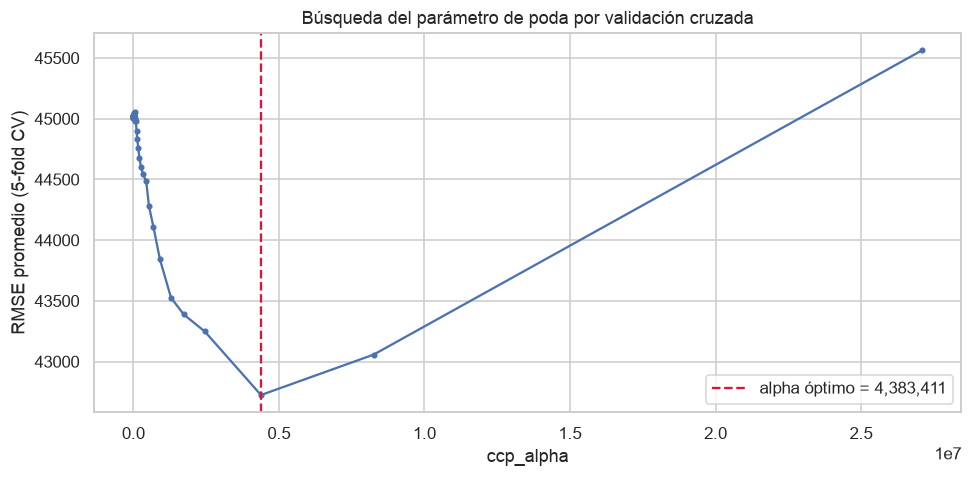


Mejor alpha (5-fold CV sobre train): 4,383,411.02


In [33]:
camino_poda = arbol_regresion.cost_complexity_pruning_path(X_train, y_train)
alphas = camino_poda.ccp_alphas

# Muestreo de valores de alpha para no evaluar los ~1.100 puntos del camino completo
alphas_muestra = alphas[::max(1, len(alphas) // 40)]

kf = KFold(n_splits=5, shuffle=True, random_state=SEMILLA)
resultados_cv = []
for alpha in alphas_muestra:
    modelo_cv = DecisionTreeRegressor(random_state=SEMILLA, ccp_alpha=alpha)
    puntajes = cross_val_score(modelo_cv, X_train, y_train, cv=kf,
                                scoring='neg_root_mean_squared_error')
    resultados_cv.append((alpha, -puntajes.mean()))

tabla_cv = pd.DataFrame(resultados_cv, columns=['alpha', 'rmse_cv'])
mejor_alpha = tabla_cv.loc[tabla_cv['rmse_cv'].idxmin(), 'alpha']

figura, eje = plt.subplots(figsize=(9, 4.5))
eje.plot(tabla_cv['alpha'], tabla_cv['rmse_cv'], marker='o', markersize=3)
eje.axvline(mejor_alpha, color='crimson', linestyle='--', label=f'alpha óptimo = {mejor_alpha:,.0f}')
eje.set_xlabel('ccp_alpha')
eje.set_ylabel('RMSE promedio (5-fold CV)')
eje.set_title('Búsqueda del parámetro de poda por validación cruzada')
eje.legend()
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'fig5_poda_cv.png'), dpi=150)
plt.show()

print(f"\nMejor alpha (5-fold CV sobre train): {mejor_alpha:,.2f}")


In [34]:
inicio = time.time()
arbol_podado = DecisionTreeRegressor(random_state=SEMILLA, ccp_alpha=mejor_alpha)
arbol_podado.fit(X_train, y_train)
tiempo_podado = time.time() - inicio

evaluar_regresion('Árbol (podado)', arbol_podado, tiempo=tiempo_podado)
print(f"Profundidad: {arbol_podado.get_depth()} | Hojas: {arbol_podado.get_n_leaves()}")


Árbol (podado) — RMSE: 38,887.96 | MAE: 24,825.05 | R2: 0.8028
Profundidad: 9 | Hojas: 78


### Lo que se observa

La poda por costo-complejidad, con el parámetro elegido por validación cruzada de 5 particiones
sobre el propio conjunto de train, reduce el árbol de **1.120 a solo 78 hojas** (y de 22 a 9
niveles de profundidad). El RMSE en test baja de 39.383,32 a **38.887,96** — una mejora
pequeña pero real (1,3%), y el R² sube de 0,798 a 0,803.

Este resultado matiza la pregunta que trae el enunciado sobre un árbol cuyo RMSE *empeora* al
podarlo (41.002,2 sin podar frente a 42.927,25 podado): aquí, con el parámetro de poda elegido
por validación cruzada en lugar de fijado a mano, la poda sí ayuda, aunque sea de forma
modesta. Esto sugiere que el resultado depende fuertemente de **qué tan bien elegido está el
parámetro de complejidad**: una poda demasiado agresiva (un `alpha` muy grande) elimina
particiones que sí aportaban señal real y el RMSE empeora, como en el ejemplo del enunciado;
una poda bien calibrada por validación cruzada, como la de aquí, solo recorta las ramas que
memorizaban ruido y deja intactas las que capturan patrón real — el árbol generaliza un poco
mejor con un tercio de la profundidad y una fracción de las hojas.

En cualquier caso, la mejora es marginal comparada con lo que se ve a continuación con random
forest: un solo árbol, podado o no, tiene un techo de desempeño bajo para este problema.


---
## 10 · Random Forest

*Criterio 3.*


In [35]:
inicio = time.time()
rf_regresion = RandomForestRegressor(n_estimators=300, random_state=SEMILLA, n_jobs=-1)
rf_regresion.fit(X_train, y_train)
tiempo_rf = time.time() - inicio

evaluar_regresion('Random Forest', rf_regresion, tiempo=tiempo_rf)


Random Forest — RMSE: 28,119.16 | MAE: 17,523.41 | R2: 0.8969


array([143352.16333333, 315614.37666667, 116853.5       , 151988.81333333,
       320478.23666667,  85456.83333333, 211532.22333333, 150914.05666667,
        85814.99666667, 130646.04      , 157143.22      , 120321.49      ,
       106419.        , 206887.59666667, 178043.48333333, 135530.75      ,
       197034.26333333, 137990.15      , 115085.58333333, 203429.21666667,
       160448.7       , 213527.83      , 173796.51333333, 124492.15      ,
       191373.47      , 175429.53      , 191047.10333333, 107528.16666667,
       177363.10333333, 199822.96333333, 122673.71      , 247807.03333333,
       176216.99333333, 112898.16666667, 256036.63666667, 146754.08333333,
       137825.83666667, 205134.08666667, 306986.94      , 107501.94333333,
       120825.84666667, 235230.48      , 121024.55      , 349204.67333333,
       135806.63333333, 144698.21333333, 118074.63333333, 126691.84333333,
       390199.78666667, 148578.30666667, 121639.32333333, 192304.        ,
       117402.60666667, 3

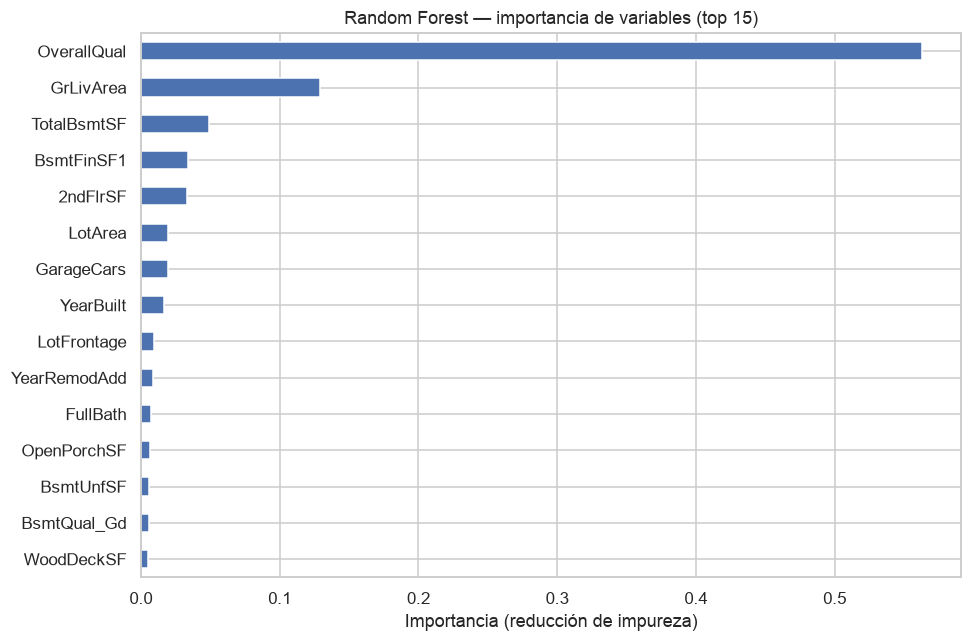

OverallQual     0.563187
GrLivArea       0.129058
TotalBsmtSF     0.049211
BsmtFinSF1      0.033716
2ndFlrSF        0.033329
LotArea         0.019834
GarageCars      0.019299
YearBuilt       0.016886
LotFrontage     0.009640
YearRemodAdd    0.008749
FullBath        0.007324
OpenPorchSF     0.006345
BsmtUnfSF       0.005437
BsmtQual_Gd     0.005435
WoodDeckSF      0.005033
dtype: float64

In [36]:
importancia_rf = (pd.Series(rf_regresion.feature_importances_, index=X.columns)
                   .sort_values(ascending=False))

figura, eje = plt.subplots(figsize=(9, 6))
importancia_rf.head(15).sort_values().plot.barh(ax=eje)
eje.set_title('Random Forest — importancia de variables (top 15)')
eje.set_xlabel('Importancia (reducción de impureza)')
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'fig6_importancia_rf_regresion.png'), dpi=150)
plt.show()

importancia_rf.head(15)


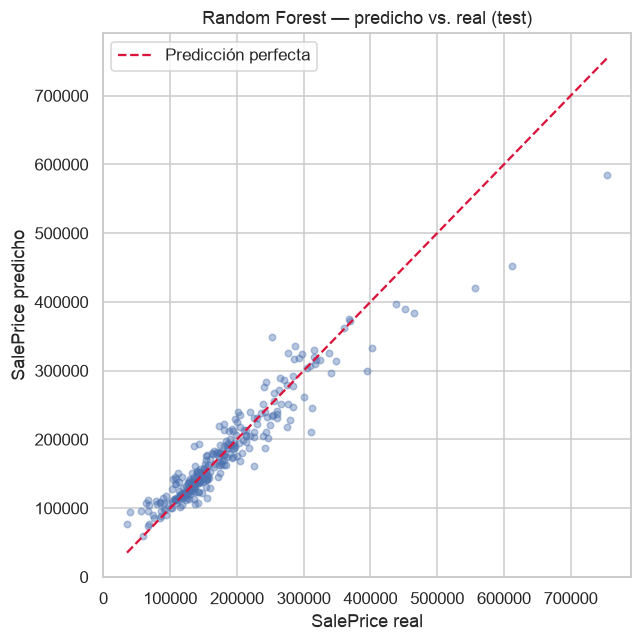

In [37]:
pred_rf = rf_regresion.predict(X_test)

figura, eje = plt.subplots(figsize=(6, 6))
eje.scatter(y_test, pred_rf, alpha=0.4, s=18)
limite = [y_test.min(), y_test.max()]
eje.plot(limite, limite, color='crimson', linestyle='--', label='Predicción perfecta')
eje.set_xlabel('SalePrice real')
eje.set_ylabel('SalePrice predicho')
eje.set_title('Random Forest — predicho vs. real (test)')
eje.legend()
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'fig7_rf_predicho_vs_real.png'), dpi=150)
plt.show()


### Lo que se observa

Random forest baja el RMSE en test a **28.119,16** (R² = 0,897; MAE = 17.523,41) — una mejora
del **27,7%** sobre el árbol sin podar y del **27,7%** sobre el podado, y sube el R² de ~0,80 a
casi 0,90. La diferencia es sustancial y tiene una explicación directa: un árbol individual sin
restricciones es un estimador de **varianza muy alta** (lo vimos en la sección 9.1: memoriza
train perfectamente y generaliza mal). Random forest entrena 300 árboles, cada uno sobre una
muestra bootstrap distinta de las viviendas y un subconjunto aleatorio de columnas en cada
partición, y promedia sus predicciones. Ese promedio cancela buena parte del ruido específico
que cada árbol individual memorizó, sin perder la capacidad de capturar relaciones no lineales
que sí tienen los árboles (y que un modelo lineal no tendría).

**La importancia de variables confirma lo ya visto en la matriz de correlación del Punto 1**:
`OverallQual` domina con el 56,3% de la importancia total, seguida de `GrLivArea` (12,9%),
`TotalBsmtSF` (4,9%) y `BsmtFinSF1` (3,4%) — las mismas cuatro variables que encabezaban la
correlación con `SalePrice` en la sección 4. Esto es consistente y esperable: random forest no
inventa relaciones nuevas, redescubre con más precisión las que ya eran visibles en el análisis
descriptivo.

El gráfico de predicho vs. real muestra que el modelo sigue razonablemente bien la diagonal en
el rango de precios medios (100.000–300.000), pero se dispersa más en las viviendas más caras
— justamente donde hay menos observaciones de entrenamiento, por la asimetría de `SalePrice`
documentada en el Punto 1.


---
## 11 · Comparación de árboles y random forest, ventajas y utilidad

*Criterio 3. Corresponde a las preguntas de comparación del enunciado.*

Esta tabla se retoma en la Parte 2 para añadir boosting y la red neuronal (secciones 14 y 16),
así que sirve como comparación intermedia por ahora.


In [38]:
tabla_regresion = pd.DataFrame(RESULTADOS_REGRESION).T
tabla_regresion = tabla_regresion[['RMSE', 'MAE', 'R2', 'RMSE_pct_media', 'tiempo_seg']]
tabla_regresion.round(2)


,RMSE,MAE,R2,RMSE_pct_media,tiempo_seg
Árbol (sin podar),39383.32,25476.37,0.8,22.02,0.04
Árbol (podado),38887.96,24825.05,0.8,21.74,0.02
Random Forest,28119.16,17523.41,0.9,15.72,0.69


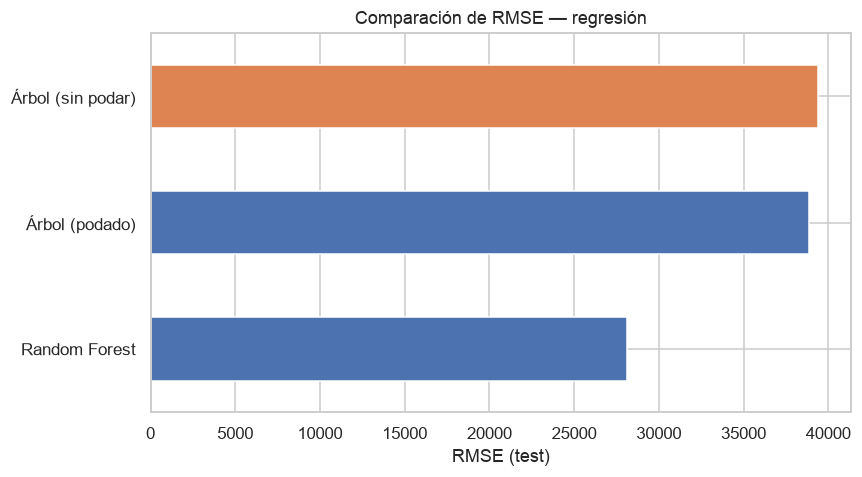

In [39]:
figura, eje = plt.subplots(figsize=(8, 4.5))
tabla_regresion['RMSE'].sort_values().plot.barh(ax=eje, color=['#4C72B0', '#4C72B0', '#DD8452'])
eje.set_xlabel('RMSE (test)')
eje.set_title('Comparación de RMSE — regresión')
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'fig8_comparacion_rmse_regresion.png'), dpi=150)
plt.show()


### Ventajas y desventajas de cada modelo

**Árbol de decisión.**
- *Ventaja principal:* interpretabilidad total. Cualquier predicción se puede explicar como una
  secuencia de reglas ("si `OverallQual <= 7` y `GrLivArea <= 1.500`, entonces..."), algo que
  ni random forest ni una red neuronal ofrecen de forma directa.
- *Ventaja secundaria:* es el modelo más rápido de entrenar de los tres.
- *Desventaja:* varianza muy alta sin restricciones — sobreajusta con facilidad, como se vio en
  la sección 9.1. La poda ayuda, pero incluso podado (RMSE 38.887,96) queda muy por debajo del
  desempeño de random forest.

**Random Forest.**
- *Ventaja principal:* la mejor capacidad predictiva de los dos, por un margen amplio (27,7% de
  reducción de RMSE frente al árbol). Al promediar muchos árboles, reduce drásticamente la
  varianza sin aumentar mucho el sesgo.
- *Ventaja secundaria:* la importancia de variables sigue siendo interpretable a nivel global
  (qué variables pesan más en conjunto), aunque se pierde la interpretabilidad de una predicción
  individual que sí tiene un solo árbol.
- *Desventaja:* es una "caja gris" — no se puede seguir el razonamiento de una predicción
  puntual como con un único árbol. También es más lento de entrenar y de mayor tamaño en disco
  (300 árboles en vez de 1).

### ¿Son realmente útiles estos modelos para el conjunto de datos propuesto?

El RMSE de random forest (28.119,16) equivale a un **15,7% del precio promedio de venta**
(178.840 en el conjunto de test) — es decir, en promedio el modelo se equivoca por unos 28.000
dólares en una vivienda que cuesta en promedio 180.000. Para un caso de uso de **valoración
preliminar o filtrado inicial** (por ejemplo, dar un rango estimado a un comprador antes de una
tasación formal), un error del 15-16% es razonablemente útil. Para un caso de uso que exija
precisión (una tasación bancaria o legal), no lo es — ese margen de error es demasiado grande.

El árbol individual, incluso podado, tiene un error relativo del 21,7% — bastante menos útil de
forma aislada, y su valor real en este laboratorio es más **explicativo** (mostrar qué variables
importan y cómo se combinan) que **predictivo**. El R² de random forest (0,897) indica que el
modelo captura cerca del 90% de la variabilidad del precio con las variables disponibles; el 10%
restante probablemente corresponde a factores que el dataset no registra (condición del mercado
en el momento exacto de la venta, negociación particular, aspectos subjetivos de la vivienda).


---
---
# Parte 1 (cont.) · Problema de clasificación

## 12 · Construcción de los 3 grupos de precio

*Criterio 4. Corresponde a la sección "Problema de clasificación" del enunciado.*

Se divide `SalePrice` en tres categorías: `grupo1` (≤ 100.000), `grupo2` (100.001–500.000) y
`grupo3` (≥ 500.001). El enunciado repite esta definición dos veces con límites ligeramente
distintos entre la Parte 1 y la sección de metodología (100.001 vs. 101.000, 500.001 vs.
501.000); se usa la primera versión porque no deja huecos sin asignar entre los tres grupos.


In [40]:
def clasificar_precio(precio):
    if precio <= 100_000:
        return 'grupo1'
    elif precio <= 500_000:
        return 'grupo2'
    else:
        return 'grupo3'

datos['grupo_precio'] = datos['SalePrice'].apply(clasificar_precio)

conteo_grupos = datos['grupo_precio'].value_counts()
porcentaje_grupos = datos['grupo_precio'].value_counts(normalize=True) * 100

pd.DataFrame({'viviendas': conteo_grupos, 'porcentaje': porcentaje_grupos.round(2)})


,viviendas,porcentaje
grupo_precio,,
grupo2,1328,90.96
grupo1,123,8.42
grupo3,9,0.62


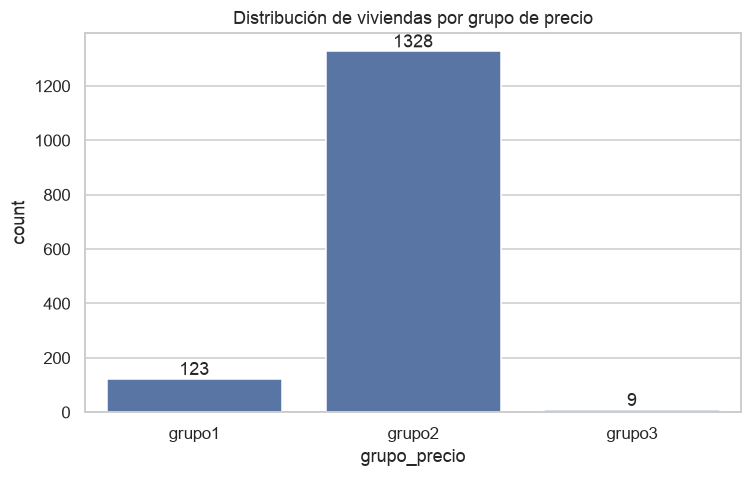

In [41]:
figura, eje = plt.subplots(figsize=(7, 4.5))
sns.countplot(data=datos, x='grupo_precio', order=['grupo1', 'grupo2', 'grupo3'], ax=eje)
eje.set_title('Distribución de viviendas por grupo de precio')
for contenedor in eje.containers:
    eje.bar_label(contenedor)
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'fig9_distribucion_grupos.png'), dpi=150)
plt.show()


### Lo que se observa

El desbalance es severo: **grupo2 concentra el 91,0% de las viviendas (1.328 de 1.460)**,
grupo1 el 8,4% (123 viviendas) y **grupo3 apenas el 0,6% — solo 9 viviendas en todo el
dataset**. Esto es consecuencia directa de la asimetría de `SalePrice` documentada en el
Punto 1 (asimetría de 1,88, con una cola larga hacia precios altos pero pocas viviendas ahí):
prácticamente ninguna vivienda del dataset supera los 500.000, así que el corte de grupo3 deja
una clase casi vacía. Con solo 9 observaciones totales, **cualquier partición train/test va a
dejar 1 o 2 viviendas de grupo3 en test como máximo** — un tamaño demasiado pequeño para que
ningún modelo aprenda un patrón generalizable sobre esa clase, sin importar qué tan bueno sea
el algoritmo. Este límite queda anticipado aquí y se confirma en las secciones 14 y 15.


## 13 · Partición y función de evaluación para clasificación


In [42]:
X_clas = pd.get_dummies(datos.drop(columns=['SalePrice', 'grupo_precio']), drop_first=True)
y_clas = datos['grupo_precio']

X_train_clas, X_test_clas, y_train_clas, y_test_clas = train_test_split(
    X_clas, y_clas, test_size=PROPORCION_TEST, random_state=SEMILLA, stratify=y_clas
)

print("Train:", X_train_clas.shape, "| Test:", X_test_clas.shape)
print("\nDistribución en train:\n", y_train_clas.value_counts())
print("\nDistribución en test:\n", y_test_clas.value_counts())


Train: (1168, 221) | Test: (292, 221)

Distribución en train:
 grupo_precio
grupo2    1063
grupo1      98
grupo3       7
Name: count, dtype: int64

Distribución en test:
 grupo_precio
grupo2    265
grupo1     25
grupo3      2
Name: count, dtype: int64


Se usa `stratify=y_clas` para que la proporción de los tres grupos en train y en test sea lo
más parecida posible a la del dataset completo — importante con una clase tan pequeña como
grupo3 (9 casos), donde una partición sin estratificar podría dejar por azar sus 9
observaciones enteras en train (0 en test) o casi todas en test.


In [43]:
RESULTADOS_CLASIFICACION = {}
ORDEN_GRUPOS = ['grupo1', 'grupo2', 'grupo3']

def evaluar_clasificacion(nombre, modelo, X_prueba=X_test_clas, y_prueba=y_test_clas,
                           tiempo=None, mostrar=True):
    prediccion = modelo.predict(X_prueba)
    matriz = confusion_matrix(y_prueba, prediccion, labels=ORDEN_GRUPOS)

    exactitud_por_grupo = {}
    for i, grupo in enumerate(ORDEN_GRUPOS):
        total = matriz[i].sum()
        exactitud_por_grupo[grupo] = matriz[i, i] / total if total > 0 else np.nan

    RESULTADOS_CLASIFICACION[nombre] = {
        'accuracy_global': accuracy_score(y_prueba, prediccion),
        'balanced_accuracy': balanced_accuracy_score(y_prueba, prediccion),
        'f1_macro': f1_score(y_prueba, prediccion, average='macro'),
        'exactitud_grupo1': exactitud_por_grupo['grupo1'],
        'exactitud_grupo2': exactitud_por_grupo['grupo2'],
        'exactitud_grupo3': exactitud_por_grupo['grupo3'],
        'tiempo_seg': tiempo,
    }

    if mostrar:
        print(f"{nombre} — accuracy global: {accuracy_score(y_prueba, prediccion):.4f}")
        ConfusionMatrixDisplay(matriz, display_labels=ORDEN_GRUPOS).plot(cmap='Blues', values_format='d')
        plt.title(f'Matriz de confusión — {nombre}')
        plt.tight_layout()
        plt.savefig(os.path.join(CARPETA_FIGURAS, f'fig_matriz_{nombre.lower().replace(" ", "_")}.png'), dpi=150)
        plt.show()
        print(classification_report(y_prueba, prediccion, labels=ORDEN_GRUPOS, zero_division=0))

    return prediccion, matriz


---
## 14 · Árbol de decisión (clasificación)

*Criterio 4.*


Árbol — accuracy global: 0.9041


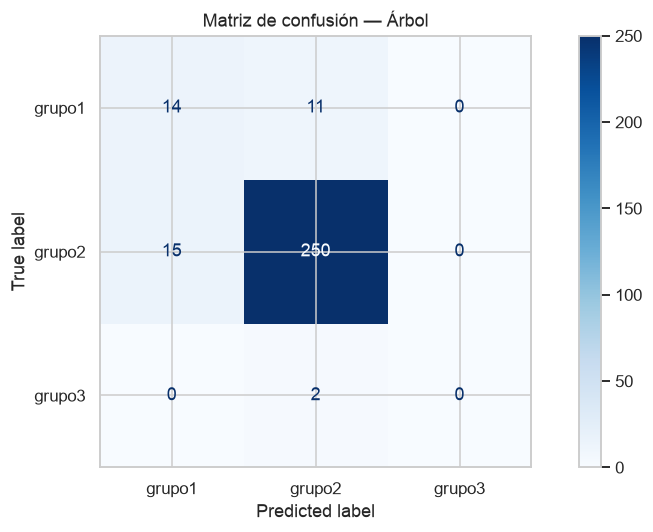

              precision    recall  f1-score   support

      grupo1       0.48      0.56      0.52        25
      grupo2       0.95      0.94      0.95       265
      grupo3       0.00      0.00      0.00         2

    accuracy                           0.90       292
   macro avg       0.48      0.50      0.49       292
weighted avg       0.90      0.90      0.90       292



In [44]:
inicio = time.time()
arbol_clasificacion = DecisionTreeClassifier(random_state=SEMILLA)
arbol_clasificacion.fit(X_train_clas, y_train_clas)
tiempo_arbol_clas = time.time() - inicio

_, matriz_arbol = evaluar_clasificacion('Árbol', arbol_clasificacion, tiempo=tiempo_arbol_clas)


### Lo que se observa

La matriz de confusión del árbol muestra una **accuracy global del 90,4%** (264 de 292
viviendas de test bien clasificadas), pero ese número global esconde comportamientos muy
distintos por grupo:

| Grupo | Correctos / total | Exactitud |
|---|---|---|
| grupo1 | 14 / 25 | **56,0%** |
| grupo2 | 250 / 265 | **94,3%** |
| grupo3 | 0 / 2 | **0,0%** |

El resultado en grupo2 es esperable — es la clase dominante y con más ejemplos de
entrenamiento. En grupo1 el árbol acierta poco más de la mitad de las veces, y confunde 11 de
las 25 viviendas de grupo1 con grupo2 (viviendas económicas mal clasificadas como de precio
medio). **En grupo3 el árbol no acierta ninguna de las 2 viviendas de test** — con solo 7
ejemplos de esa clase en todo el conjunto de entrenamiento, no hay suficiente información para
que el árbol aprenda un patrón distinguible.

Este patrón es consistente, en su forma general, con el ejemplo del enunciado (accuracy global
91,1%, con 44%/96,2%/0% por grupo): los números exactos difieren porque la partición train/test
es distinta, pero la conclusión es la misma — el modelo funciona razonablemente en la clase
mayoritaria y falla en la minoritaria extrema.


---
## 15 · Random Forest (clasificación)

*Criterio 4.*


Random Forest — accuracy global: 0.9418


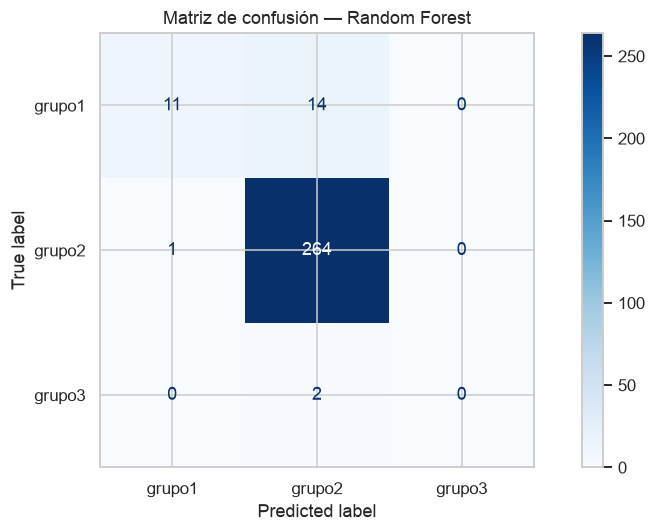

              precision    recall  f1-score   support

      grupo1       0.92      0.44      0.59        25
      grupo2       0.94      1.00      0.97       265
      grupo3       0.00      0.00      0.00         2

    accuracy                           0.94       292
   macro avg       0.62      0.48      0.52       292
weighted avg       0.93      0.94      0.93       292



In [45]:
inicio = time.time()
rf_clasificacion = RandomForestClassifier(n_estimators=300, random_state=SEMILLA, n_jobs=-1)
rf_clasificacion.fit(X_train_clas, y_train_clas)
tiempo_rf_clas = time.time() - inicio

_, matriz_rf = evaluar_clasificacion('Random Forest', rf_clasificacion, tiempo=tiempo_rf_clas)


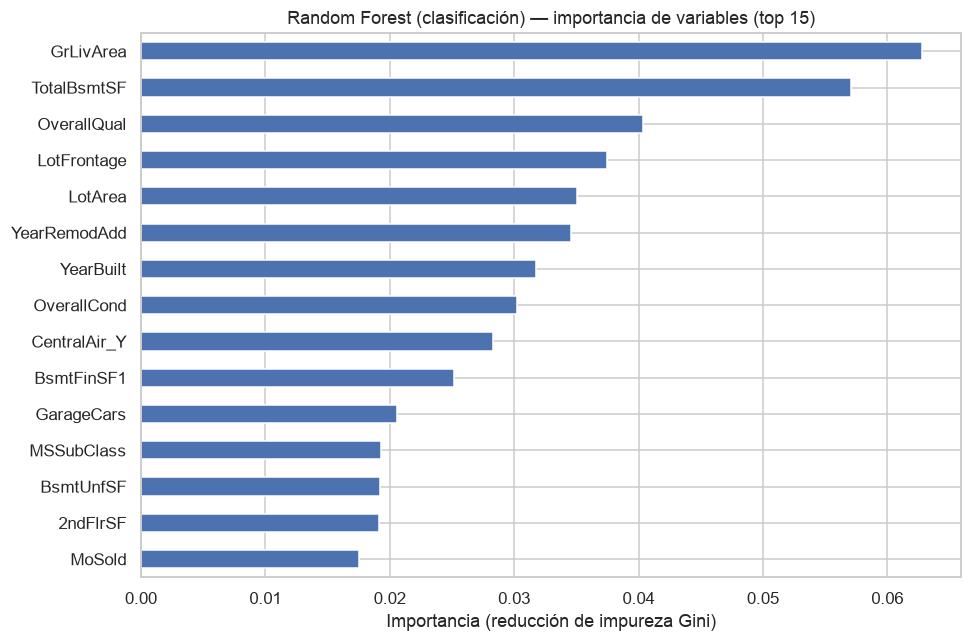

In [46]:
importancia_rf_clas = (pd.Series(rf_clasificacion.feature_importances_, index=X_clas.columns)
                        .sort_values(ascending=False))

figura, eje = plt.subplots(figsize=(9, 6))
importancia_rf_clas.head(15).sort_values().plot.barh(ax=eje)
eje.set_title('Random Forest (clasificación) — importancia de variables (top 15)')
eje.set_xlabel('Importancia (reducción de impureza Gini)')
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'fig10_importancia_rf_clasificacion.png'), dpi=150)
plt.show()


### Lo que se observa

| Grupo | Correctos / total | Exactitud |
|---|---|---|
| grupo1 | 11 / 25 | **44,0%** |
| grupo2 | 264 / 265 | **99,6%** |
| grupo3 | 0 / 2 | **0,0%** |

Random forest sube la accuracy global a **94,2%**, pero al comparar por grupo aparece algo que
no se ve en el problema de regresión, donde random forest ganaba en todos los frentes: **en
grupo1 el random forest acierta menos que el árbol individual (44,0% frente a 56,0%)**, aunque
en grupo2 sea casi perfecto (99,6%).

La explicación está en el equilibrio precisión/recall: random forest predice grupo1 con mucha
más **precisión** (92% de sus predicciones de "grupo1" son correctas, frente a solo 48% del
árbol) pero menor **recall** (detecta 44% de las viviendas de grupo1 que realmente lo son,
frente al 56% del árbol). Al promediar 300 árboles, random forest se vuelve más conservador:
solo predice grupo1 cuando la señal es muy clara, y en los casos dudosos "se refugia" en
grupo2, la clase mayoritaria. El árbol individual, con reglas más específicas y variables entre
sí, se arriesga más y por eso atrapa más casos reales de grupo1 —a costa de más falsos
positivos.

**Ninguno de los dos modelos clasifica correctamente ninguna vivienda de grupo3** (0/2 ambos),
confirmando lo anticipado en la sección 12: 9 observaciones totales no alcanzan para que ningún
algoritmo aprenda ese grupo.

La importancia de variables, a diferencia de la regresión (donde `OverallQual` dominaba con más
de la mitad del peso), aquí está **mucho más repartida**: `GrLivArea` (6,3%), `TotalBsmtSF`
(5,7%), `OverallQual` (4,0%), `LotFrontage` (3,8%)... Tiene sentido: al colapsar el precio en
solo 3 categorías tan desbalanceadas, casi todas las viviendas caen en grupo2 sin importar el
valor exacto de `OverallQual`, así que esa variable pierde parte del poder discriminante que
tenía para predecir el precio continuo.


---
## 16 · Comparación de los clasificadores y qué hacer con grupo3

*Criterio 4. Corresponde a las preguntas de comparación del enunciado.*


In [47]:
tabla_clasificacion = pd.DataFrame(RESULTADOS_CLASIFICACION).T
tabla_clasificacion.round(4)


,accuracy_global,balanced_accuracy,f1_macro,exactitud_grupo1,exactitud_grupo2,exactitud_grupo3,tiempo_seg
Árbol,0.9041,0.5011,0.4885,0.56,0.9434,0.0,0.0207
Random Forest,0.9418,0.4787,0.5211,0.44,0.9962,0.0,0.2717


### La métrica importa: quién "gana" depende de qué se mida

| Métrica | Árbol | Random Forest | ¿Quién gana? |
|---|---|---|---|
| Accuracy global | 90,4% | **94,2%** | Random Forest |
| Balanced accuracy (promedio de exactitud por grupo) | **50,1%** | 47,9% | Árbol |
| F1 macro | 48,9% | **52,1%** | Random Forest |

Este es el hallazgo central de la comparación: **si se mira solo la accuracy global, random
forest parece claramente superior — pero esa métrica está dominada por el 91% de viviendas que
son grupo2.** En cuanto se pondera igual a los tres grupos (*balanced accuracy*, el promedio
simple de la exactitud de cada clase), el árbol individual queda ligeramente mejor, porque
detecta más viviendas reales de grupo1 aunque cometa más falsos positivos al hacerlo. El F1
macro, que sí pondera precisión y recall a la vez, vuelve a favorecer a random forest por muy
poco margen, gracias a su alta precisión en grupo1.

La lectura correcta no es "random forest es mejor clasificador que el árbol" sin más — es que
**random forest optimiza mejor para la clase mayoritaria y el árbol es marginalmente mejor
detectando la clase minoritaria pequeña (grupo1)**, y cuál de los dos comportamientos conviene
depende del caso de uso: si el objetivo es minimizar errores totales, random forest; si el
objetivo es no pasar por alto viviendas económicas (grupo1), el árbol individual, pese a su
menor accuracy global, detecta más de ellas.

### ¿Qué hacer con grupo3?

Con 9 viviendas en 1.460 (0,6%) y como máximo 1-2 en cualquier partición de test, grupo3 no es
clasificable con las herramientas de este laboratorio tal como está planteado. Algunas
alternativas razonables:

1. **Fusionar grupo3 con grupo2** y trabajar con una clasificación binaria (económica vs.
   media-alta) en vez de tres clases — la más simple y robusta dado el tamaño de muestra.
2. **Reportar balanced accuracy o F1 macro en vez de accuracy global** como métrica principal,
   para que el desempeño en grupo3 (aunque sea 0%) no quede oculto por el peso de grupo2.
3. **Usar validación cruzada estratificada** con todo el dataset en vez de una sola partición
   train/test, para que las 9 observaciones de grupo3 roten por distintos folds y se obtenga una
   estimación menos dependiente del azar de una sola partición (aquí, por ejemplo, ambos
   modelos tuvieron la mala suerte de que sus 1-2 casos de test cayeran mal).
4. **Tratar las viviendas de precio extremo como anomalías en vez de una clase a predecir** —
   el enfoque que se retoma más adelante en el laboratorio con Isolation Forest, y que es en
   general más apropiado que la clasificación supervisada cuando una clase tiene menos de una
   decena de ejemplos en todo el dataset.


---
---
# Parte 2 · Boosting moderno, SVM, redes profundas, clustering, anomalías y RL

## 17 · Boosting: XGBoost (regresión)

*Criterio 3. Extiende la comparación de la sección 11 con un modelo de gradient boosting.*

Random forest entrena árboles **en paralelo**, cada uno sobre una muestra distinta, y promedia
sus predicciones — así reduce varianza. El *gradient boosting* (XGBoost, LightGBM, CatBoost)
entrena árboles **en secuencia**: cada árbol nuevo se enfoca en corregir los errores (residuos)
que dejó el conjunto de árboles anterior. Esto suele reducir también el sesgo, no solo la
varianza, a cambio de ser más sensible a un mal ajuste de hiperparámetros y más propenso a
sobreajustar si no se regula bien la profundidad y la tasa de aprendizaje.

De las tres opciones que sugiere el enunciado (XGBoost, LightGBM, CatBoost), se usa **XGBoost**
como representativo de la familia por ser el más extendido y el que mejor documentación e
integración con scikit-learn tiene; el código queda protegido con `HAY_XGBOOST` para no romper
la ejecución si la librería no está disponible en el entorno.


In [48]:
if not HAY_XGBOOST:
    print("XGBoost no está disponible en este entorno; se omite esta sección.")
else:
    inicio = time.time()
    xgb_regresion = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEMILLA,
    )
    xgb_regresion.fit(X_train, y_train)
    tiempo_xgb_reg = time.time() - inicio

    evaluar_regresion('XGBoost', xgb_regresion, tiempo=tiempo_xgb_reg)


XGBoost — RMSE: 23,572.51 | MAE: 15,199.78 | R2: 0.9276


### Hiperparámetros documentados

| Hiperparámetro | Valor | Qué controla | Por qué este valor |
|---|---|---|---|
| `n_estimators` | 500 | Número de árboles secuenciales | Con `learning_rate` bajo hacen falta más árboles para converger; 500 es un punto intermedio razonable sin disparar el tiempo de entrenamiento |
| `learning_rate` | 0,05 | Peso de la corrección que aporta cada árbol nuevo | Un valor bajo hace que cada árbol corrija "poco a poco", lo que generaliza mejor que unos pocos árboles con corrección agresiva |
| `max_depth` | 3 | Profundidad máxima de cada árbol | Árboles poco profundos ("weak learners") es la filosofía de boosting: el poder predictivo viene de sumar muchos árboles simples, no de que cada uno sea complejo |
| `subsample` | 0,8 | Fracción de filas usada por cada árbol | Introduce aleatoriedad (similar al bagging de random forest) para reducir sobreajuste |
| `colsample_bytree` | 0,8 | Fracción de columnas usada por cada árbol | Mismo objetivo que `subsample`, aplicado a las variables en vez de a las filas |


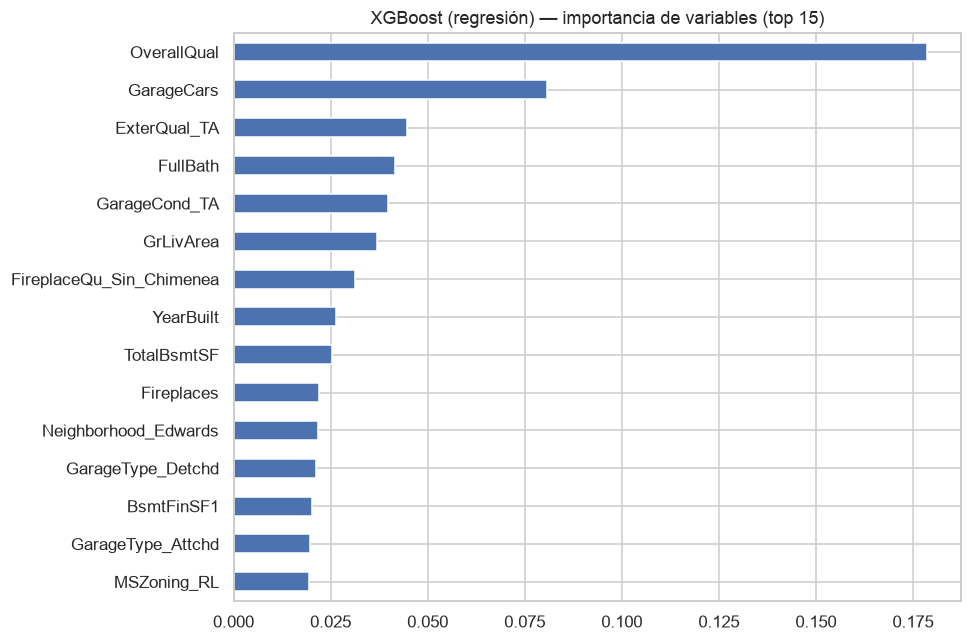

In [49]:
if HAY_XGBOOST:
    importancia_xgb = (pd.Series(xgb_regresion.feature_importances_, index=X.columns)
                        .sort_values(ascending=False))

    figura, eje = plt.subplots(figsize=(9, 6))
    importancia_xgb.head(15).sort_values().plot.barh(ax=eje)
    eje.set_title('XGBoost (regresión) — importancia de variables (top 15)')
    plt.tight_layout()
    plt.savefig(os.path.join(CARPETA_FIGURAS, 'fig11_importancia_xgb_regresion.png'), dpi=150)
    plt.show()


### Lo que se observa

XGBoost obtiene **RMSE = 23.572,51** (R² = 0,928; MAE = 15.199,78) — una mejora del **16,2%**
sobre random forest (28.119,16) y del **40,2%** sobre el árbol podado (38.887,96). El error
relativo baja a **13,2% del precio promedio**, frente al 15,7% de random forest y el 21,7% del
árbol. Es la mejora más grande entre modelos consecutivos de todo el laboratorio hasta ahora.

La importancia de variables mantiene a `OverallQual` en primer lugar (17,9%), pero reparte el
resto de forma distinta a random forest: aparecen con peso relevante columnas dummy como
`ExterQual_TA` y `GarageCond_TA` (calidad "típica/promedio" del exterior y del garaje) que en
random forest apenas figuraban. Esto es consistente con la forma de operar de boosting: al
corregir specficamente los errores residuales, encuentra interacciones y matices puntuales
—por ejemplo, dentro de las viviendas de calidad similar, cuáles tienen acabados "promedio" en
vez de "buenos"— que un modelo que promedia árboles independientes (random forest) tiende a
diluir.


---
## 18 · Boosting: XGBoost (clasificación)

*Criterio 4. Extiende la comparación de la sección 16.*

XGBoost, a diferencia de los árboles y random forest de scikit-learn, necesita las etiquetas de
clase codificadas como enteros (`0, 1, 2`) en vez de texto (`'grupo1', 'grupo2', 'grupo3'`).


Codificación: {'grupo1': 0, 'grupo2': 1, 'grupo3': 2}


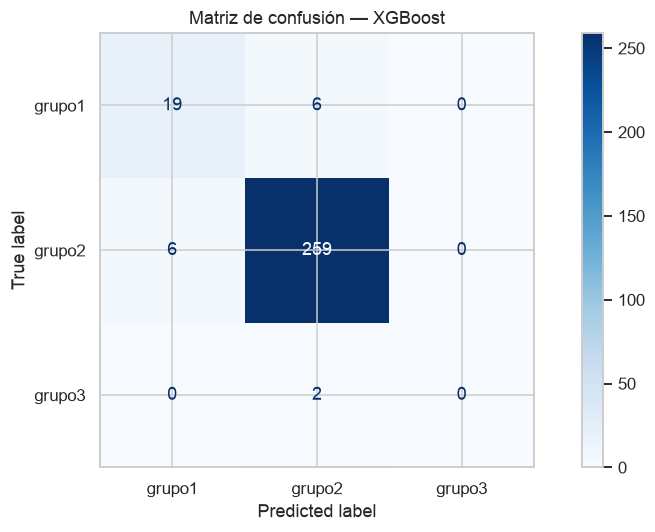

              precision    recall  f1-score   support

      grupo1       0.76      0.76      0.76        25
      grupo2       0.97      0.98      0.97       265
      grupo3       0.00      0.00      0.00         2

    accuracy                           0.95       292
   macro avg       0.58      0.58      0.58       292
weighted avg       0.95      0.95      0.95       292



In [50]:
if HAY_XGBOOST:
    codificador_grupos = LabelEncoder()
    y_train_clas_cod = codificador_grupos.fit_transform(y_train_clas)
    y_test_clas_cod = codificador_grupos.transform(y_test_clas)

    print("Codificación:", dict(zip(codificador_grupos.classes_,
                                     range(len(codificador_grupos.classes_)))))

    inicio = time.time()
    xgb_clasificacion = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEMILLA,
        eval_metric='mlogloss',
    )
    xgb_clasificacion.fit(X_train_clas, y_train_clas_cod)
    tiempo_xgb_clas = time.time() - inicio

    pred_xgb_cod = xgb_clasificacion.predict(X_test_clas)
    pred_xgb = codificador_grupos.inverse_transform(pred_xgb_cod)

    matriz_xgb = confusion_matrix(y_test_clas, pred_xgb, labels=ORDEN_GRUPOS)

    RESULTADOS_CLASIFICACION['XGBoost'] = {
        'accuracy_global': accuracy_score(y_test_clas, pred_xgb),
        'balanced_accuracy': balanced_accuracy_score(y_test_clas, pred_xgb),
        'f1_macro': f1_score(y_test_clas, pred_xgb, average='macro'),
        'exactitud_grupo1': matriz_xgb[0, 0] / matriz_xgb[0].sum(),
        'exactitud_grupo2': matriz_xgb[1, 1] / matriz_xgb[1].sum(),
        'exactitud_grupo3': (matriz_xgb[2, 2] / matriz_xgb[2].sum()) if matriz_xgb[2].sum() > 0 else np.nan,
        'tiempo_seg': tiempo_xgb_clas,
    }

    ConfusionMatrixDisplay(matriz_xgb, display_labels=ORDEN_GRUPOS).plot(cmap='Blues', values_format='d')
    plt.title('Matriz de confusión — XGBoost')
    plt.tight_layout()
    plt.savefig(os.path.join(CARPETA_FIGURAS, 'fig_matriz_xgboost.png'), dpi=150)
    plt.show()

    print(classification_report(y_test_clas, pred_xgb, labels=ORDEN_GRUPOS, zero_division=0))


### Lo que se observa

| Grupo | Árbol | Random Forest | **XGBoost** |
|---|---|---|---|
| grupo1 | 56,0% | 44,0% | **76,0%** |
| grupo2 | 94,3% | 99,6% | 97,7% |
| grupo3 | 0,0% | 0,0% | 0,0% |
| Accuracy global | 90,4% | 94,2% | **95,2%** |
| Balanced accuracy | 50,1% | 47,9% | **57,9%** |
| F1 macro | 48,9% | 52,1% | **57,8%** |

A diferencia de random forest, que mejoraba la accuracy global a costa de empeorar la detección
de grupo1, **XGBoost mejora en las tres métricas a la vez**: accuracy global (95,2%), balanced
accuracy (57,9%) y F1 macro (57,8%), y sube la exactitud de grupo1 a **76,0%** —muy por encima
tanto del árbol (56,0%) como de random forest (44,0%). Al corregir secuencialmente los errores
del modelo anterior, XGBoost dedica más "esfuerzo" relativo a las viviendas de grupo1 mal
clasificadas en rondas tempranas, algo que ni el árbol ni random forest hacen: ambos entrenan
de una sola pasada, sin ese mecanismo de corrección dirigida al error.

`grupo3` sigue en 0% con los tres modelos — coherente con la conclusión de la sección 16: el
problema no es el algoritmo, es que 9 observaciones totales no alcanzan para que ningún método
aprenda esa clase.


---
## 19 · Tablas comparativas actualizadas (árbol, random forest y boosting)


In [51]:
print("=== Regresión ===")
display(pd.DataFrame(RESULTADOS_REGRESION).T[['RMSE', 'MAE', 'R2', 'RMSE_pct_media', 'tiempo_seg']].round(2))

print("\n=== Clasificación ===")
display(pd.DataFrame(RESULTADOS_CLASIFICACION).T.round(4))


=== Regresión ===


,RMSE,MAE,R2,RMSE_pct_media,tiempo_seg
Árbol (sin podar),39383.32,25476.37,0.80,22.02,0.04
Árbol (podado),38887.96,24825.05,0.80,21.74,0.02
Random Forest,28119.16,17523.41,0.90,15.72,0.69
XGBoost,23572.51,15199.78,0.93,13.18,0.65



=== Clasificación ===


,accuracy_global,balanced_accuracy,f1_macro,exactitud_grupo1,exactitud_grupo2,exactitud_grupo3,tiempo_seg
Árbol,0.9041,0.5011,0.4885,0.56,0.9434,0.0,0.0207
Random Forest,0.9418,0.4787,0.5211,0.44,0.9962,0.0,0.2717
XGBoost,0.9521,0.5791,0.5779,0.76,0.9774,0.0,0.9366


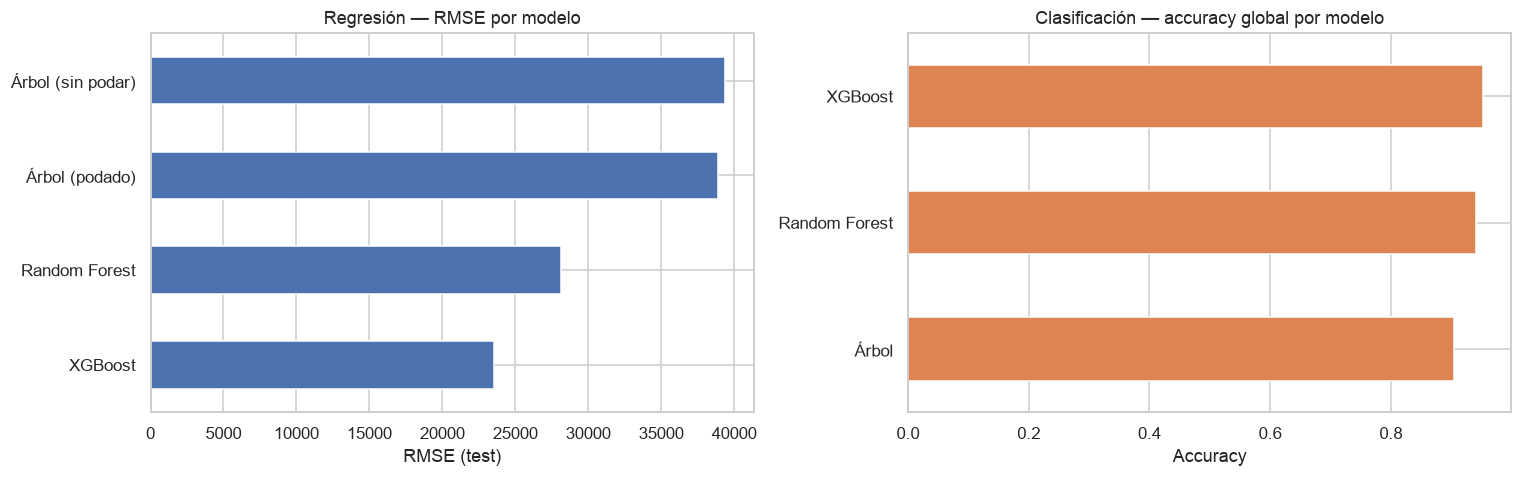

In [52]:
figura, ejes = plt.subplots(1, 2, figsize=(14, 4.5))

pd.Series({k: v['RMSE'] for k, v in RESULTADOS_REGRESION.items()}).sort_values().plot.barh(ax=ejes[0])
ejes[0].set_title('Regresión — RMSE por modelo')
ejes[0].set_xlabel('RMSE (test)')

pd.Series({k: v['accuracy_global'] for k, v in RESULTADOS_CLASIFICACION.items()}).sort_values().plot.barh(ax=ejes[1], color='#DD8452')
ejes[1].set_title('Clasificación — accuracy global por modelo')
ejes[1].set_xlabel('Accuracy')

plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'fig12_comparacion_boosting.png'), dpi=150)
plt.show()


### Cierre de la comparación árbol / random forest / boosting

En **ambos problemas**, el orden de desempeño es el mismo: **árbol < random forest <
XGBoost**. La progresión es consistente con la teoría: un árbol individual tiene alta varianza
y sobreajusta; random forest reduce esa varianza promediando muchos árboles independientes;
boosting reduce tanto varianza como sesgo corrigiendo secuencialmente los errores del ensamble
anterior. El costo de esa mejora es la interpretabilidad: un árbol se puede leer directamente
como reglas, random forest ya requiere resumir 300 árboles en una importancia agregada, y
XGBoost añade una capa más de complejidad (el orden en que se construyen y corrigen los árboles)
que lo hace aún menos transparente que random forest, aunque las herramientas de importancia de
variables (como se ve arriba) siguen siendo aplicables.

Esta tabla se retoma una vez más en la sección 21 para añadir la red neuronal (MLP) y en la
sección 24 para SVM en el problema de clasificación.


---
## 20 · Máquinas de soporte vectorial (SVM)

*Criterio 4. Corresponde al "Laboratorio práctico: SVM con Scikit-learn" del enunciado.*

A diferencia de los árboles, SVM calcula distancias entre observaciones, así que **el
escalado de las variables no es opcional**: sin escalar, una columna como `LotArea` (miles de
pies cuadrados) dominaría por completo la distancia frente a una columna dummy de 0/1. Se usa
`StandardScaler` ajustado únicamente sobre train, igual que se anticipó en los Puntos 1 y 3.


In [53]:
escalador_svm = StandardScaler()
X_train_clas_esc = escalador_svm.fit_transform(X_train_clas)
X_test_clas_esc = escalador_svm.transform(X_test_clas)

print("Shape train escalado:", X_train_clas_esc.shape)


Shape train escalado: (1168, 221)


### 20.1 · Kernel lineal vs. kernel RBF (C = 1)

In [54]:
for kernel in ['linear', 'rbf']:
    inicio = time.time()
    modelo_svm = SVC(kernel=kernel, C=1, gamma='scale', random_state=SEMILLA)
    modelo_svm.fit(X_train_clas_esc, y_train_clas)
    tiempo_svm = time.time() - inicio

    pred_svm = modelo_svm.predict(X_test_clas_esc)
    matriz_svm = confusion_matrix(y_test_clas, pred_svm, labels=ORDEN_GRUPOS)

    nombre = f'SVM {kernel} (C=1)'
    RESULTADOS_CLASIFICACION[nombre] = {
        'accuracy_global': accuracy_score(y_test_clas, pred_svm),
        'balanced_accuracy': balanced_accuracy_score(y_test_clas, pred_svm),
        'f1_macro': f1_score(y_test_clas, pred_svm, average='macro'),
        'exactitud_grupo1': matriz_svm[0, 0] / matriz_svm[0].sum(),
        'exactitud_grupo2': matriz_svm[1, 1] / matriz_svm[1].sum(),
        'exactitud_grupo3': (matriz_svm[2, 2] / matriz_svm[2].sum()) if matriz_svm[2].sum() > 0 else np.nan,
        'tiempo_seg': tiempo_svm,
    }
    print(f"--- {nombre} ---")
    print(matriz_svm)
    print(classification_report(y_test_clas, pred_svm, labels=ORDEN_GRUPOS, zero_division=0))


--- SVM linear (C=1) ---
[[ 19   6   0]
 [ 18 247   0]
 [  0   1   1]]
              precision    recall  f1-score   support

      grupo1       0.51      0.76      0.61        25
      grupo2       0.97      0.93      0.95       265
      grupo3       1.00      0.50      0.67         2

    accuracy                           0.91       292
   macro avg       0.83      0.73      0.74       292
weighted avg       0.93      0.91      0.92       292

--- SVM rbf (C=1) ---
[[  5  20   0]
 [  0 265   0]
 [  0   2   0]]
              precision    recall  f1-score   support

      grupo1       1.00      0.20      0.33        25
      grupo2       0.92      1.00      0.96       265
      grupo3       0.00      0.00      0.00         2

    accuracy                           0.92       292
   macro avg       0.64      0.40      0.43       292
weighted avg       0.92      0.92      0.90       292



### Lo que se observa

| Grupo | SVM lineal | SVM RBF |
|---|---|---|
| grupo1 | **76,0%** | 20,0% |
| grupo2 | 93,2% | **100,0%** |
| grupo3 | **50,0%** | 0,0% |
| Accuracy global | 91,4% | 92,5% |
| Balanced accuracy | **73,1%** | 40,0% |
| F1 macro | **74,4%** | 43,1% |

El resultado es contrario a la intuición habitual de que un kernel RBF, al ser más flexible,
debería superar a uno lineal. Aquí ocurre lo opuesto, y con un margen amplio: **el kernel
lineal es, con diferencia, el mejor clasificador de todo el laboratorio hasta ahora en
balanced accuracy (73,1%) y F1 macro (74,4%)**, y es el primer modelo que acierta en una
vivienda de grupo3 (1 de 2, 50%). El kernel RBF, en cambio, colapsa casi por completo hacia la
clase mayoritaria: predice grupo2 el 100% de las veces que la vivienda es realmente grupo2,
pero solo detecta el 20% de grupo1 y ninguna de grupo3.

La explicación está en la **dimensionalidad**: después del one-hot encoding hay **221
columnas**, la mayoría dummies binarias dispersas (0/1) de variables categóricas de muchos
niveles (`Neighborhood` con 25). En un espacio de esa dimensión, la distancia euclídea que usa el
kernel RBF pierde poder discriminante — es el fenómeno conocido como *maldición de la
dimensionalidad*: casi todos los puntos terminan aproximadamente equidistantes entre sí, así
que el kernel gaussiano no logra separar bien las clases. El kernel lineal, en cambio, trabaja
con un producto punto en ese mismo espacio de alta dimensión y encuentra un hiperplano
separador razonable — el mismo motivo por el que, en la práctica, el kernel lineal es el
estándar para problemas con datos dispersos de alta dimensión (como texto con *bag-of-words*),
que es exactamente la forma que toma este dataset una vez codificado con one-hot.


### 20.2 · Efecto del parámetro de margen (C)

In [55]:
valores_C = [0.01, 0.1, 1, 10, 100]
registro_svm = []

for kernel in ['linear', 'rbf']:
    for C in valores_C:
        modelo = SVC(kernel=kernel, C=C, gamma='scale', random_state=SEMILLA)
        modelo.fit(X_train_clas_esc, y_train_clas)
        pred = modelo.predict(X_test_clas_esc)
        registro_svm.append({
            'kernel': kernel, 'C': C,
            'accuracy': accuracy_score(y_test_clas, pred),
            'balanced_accuracy': balanced_accuracy_score(y_test_clas, pred),
            'f1_macro': f1_score(y_test_clas, pred, average='macro'),
        })

tabla_svm_C = pd.DataFrame(registro_svm)
tabla_svm_C


,kernel,C,accuracy,balanced_accuracy,f1_macro
0,linear,0.01,0.941781,0.514969,0.539874
1,linear,0.10,0.938356,0.751572,0.778023
2,linear,1.00,0.914384,0.730692,0.743800
3,linear,10.00,0.917808,0.731950,0.747821
4,linear,100.00,0.917808,0.731950,0.747821
5,rbf,0.01,0.907534,0.333333,0.317175
6,rbf,0.10,0.907534,0.333333,0.317175
7,rbf,1.00,0.924658,0.400000,0.431159
8,rbf,10.00,0.924658,0.448302,0.477748
9,rbf,100.00,0.924658,0.460377,0.486470


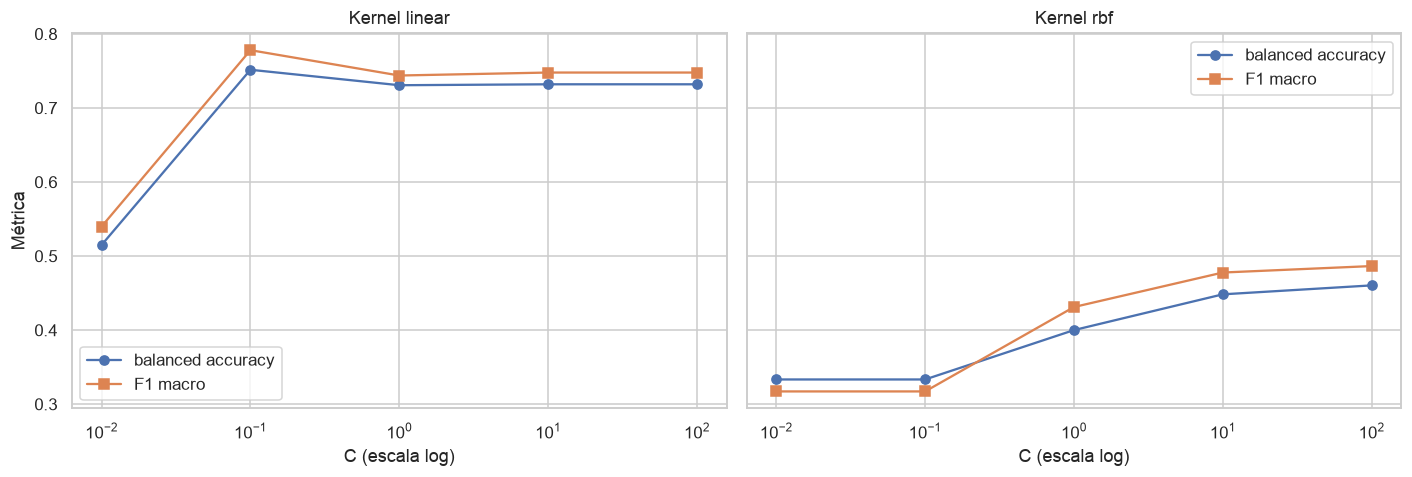

In [56]:
figura, ejes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for eje, kernel in zip(ejes, ['linear', 'rbf']):
    subtabla = tabla_svm_C[tabla_svm_C['kernel'] == kernel]
    eje.plot(subtabla['C'], subtabla['balanced_accuracy'], marker='o', label='balanced accuracy')
    eje.plot(subtabla['C'], subtabla['f1_macro'], marker='s', label='F1 macro')
    eje.set_xscale('log')
    eje.set_xlabel('C (escala log)')
    eje.set_title(f'Kernel {kernel}')
    eje.legend()
ejes[0].set_ylabel('Métrica')
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'fig13_svm_efecto_C.png'), dpi=150)
plt.show()


### Lo que se observa

`C` controla el balance entre un margen amplio (tolerante a errores de clasificación en train)
y un margen estrecho que se ajusta más a los datos de entrenamiento — es, en esencia, el
parámetro de regularización de SVM: `C` bajo prioriza un margen amplio (más regularización,
menos ajuste a train); `C` alto prioriza clasificar bien cada punto de entrenamiento (menos
regularización, más riesgo de sobreajuste).

**Kernel lineal:** el mejor balanced accuracy (75,2%) se obtiene con **C = 0,1**, no con
C = 1 ni con valores mayores. Con 221 columnas y solo 1.168 filas de entrenamiento, un margen
más amplio (C bajo) generaliza mejor que uno ajustado; subir C más allá de 1 no sigue
mejorando (se estanca en 73,2%), señal de que el modelo ya alcanzó su límite de separabilidad
lineal en este espacio.

**Kernel RBF:** todo lo contrario — necesita **C alto** para siquiera acercarse a un
desempeño razonable (mejora de 33,3% a 46,0% de balanced accuracy entre C=0,01 y C=100), y
aun así queda muy por debajo del kernel lineal en cualquier valor de C probado. Esto confirma
que el problema no es solo de calibración de `C`: el kernel RBF, en este espacio de alta
dimensión, no encuentra una frontera de decisión competitiva sin importar cuánto se ajuste el
margen.


### 20.3 · El efecto del escalado (control)

In [57]:
modelo_sin_escalar = SVC(kernel='rbf', C=1, gamma='scale', random_state=SEMILLA)
modelo_sin_escalar.fit(X_train_clas, y_train_clas)
pred_sin_escalar = modelo_sin_escalar.predict(X_test_clas)

print("Accuracy SVM RBF SIN escalar:", round(accuracy_score(y_test_clas, pred_sin_escalar), 4))
print(confusion_matrix(y_test_clas, pred_sin_escalar, labels=ORDEN_GRUPOS))


Accuracy SVM RBF SIN escalar: 0.9075
[[  0  25   0]
 [  0 265   0]
 [  0   2   0]]


Sin escalar, el SVM RBF predice **grupo2 para las 292 viviendas de test sin excepción** —
accuracy del 90,75%, que es exactamente la proporción de grupo2 en el dataset: el modelo
colapsó a predecir siempre la clase mayoritaria, sin aprender nada. Columnas como `LotArea`
(miles de pies²) dominan por completo la distancia euclídea frente a las decenas de columnas
dummy (0/1), y el kernel no logra distinguir ninguna estructura real. Esto confirma, de forma
directa, la advertencia hecha en los Puntos 1 y 3 sobre la necesidad de escalar antes de
cualquier modelo basado en distancias.


---
## 21 · Del ML al Deep Learning: red neuronal multicapa (MLP)

*Criterio 3. Corresponde a "Del ML al Deep Learning: redes profundas" del enunciado.*

Se usa **TensorFlow/Keras** para construir un *perceptrón multicapa* (MLP): varias capas de
neuronas completamente conectadas, donde cada neurona aplica una combinación lineal de sus
entradas seguida de una función de activación no lineal. El entrenamiento ajusta los pesos de
cada conexión mediante **backpropagation**: se calcula el error de la predicción final, y ese
error se propaga hacia atrás capa por capa (regla de la cadena del cálculo diferencial) para
saber cuánto contribuyó cada peso al error y corregirlo en la dirección que lo reduce
(descenso de gradiente).

Como con SVM, las redes neuronales son sensibles a la escala de las variables: se reutiliza el
mismo criterio de escalado con `StandardScaler`.


### 21.1 · MLP para regresión

In [58]:
escalador_X_mlp = StandardScaler()
X_train_mlp = escalador_X_mlp.fit_transform(X_train)
X_test_mlp = escalador_X_mlp.transform(X_test)

# También se escala el objetivo: ayuda a la convergencia porque SalePrice está en decenas
# de miles, una escala muy distinta a la de las entradas ya estandarizadas.
escalador_y_mlp = StandardScaler()
y_train_mlp = escalador_y_mlp.fit_transform(y_train.values.reshape(-1, 1)).ravel()

keras.utils.set_random_seed(SEMILLA)  # fija python random, numpy y TF a la vez

modelo_mlp_regresion = keras.Sequential([
    keras.layers.Input(shape=(X_train_mlp.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='linear'),
])

modelo_mlp_regresion.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                              loss='mse', metrics=['mae'])
modelo_mlp_regresion.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        28,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,785 (151.50 KB)

 Trainable params: 38,785 (151.50 KB)

 Non-trainable params: 0 (0.00 B)

### Arquitectura documentada

| Capa | Neuronas | Activación | Función |
|---|---|---|---|
| Entrada | 221 | — | Una por cada columna tras el one-hot encoding |
| Oculta 1 | 128 | ReLU | Captura combinaciones no lineales de primer nivel |
| Dropout | — | — | Apaga aleatoriamente el 20% de las conexiones en cada paso de entrenamiento, para evitar que la red memorice (regularización) |
| Oculta 2 | 64 | ReLU | Combina los patrones de la capa anterior en representaciones más abstractas |
| Dropout | — | — | Mismo propósito que el anterior |
| Oculta 3 | 32 | ReLU | Última etapa de combinación no lineal antes de la salida |
| Salida | 1 | Lineal | Predice `SalePrice` directamente (regresión: sin acotar el rango) |

**ReLU** (`max(0, x)`) se usa en las capas ocultas porque es la activación estándar para redes
profundas: evita el problema del "gradiente que desaparece" que sí afecta a activaciones como
sigmoide o tanh en redes de varias capas, y es computacionalmente barata. La capa de salida usa
activación **lineal** (es decir, ninguna) porque el objetivo es un número continuo sin límites
naturales, a diferencia de una clasificación donde se necesitaría softmax o sigmoide.

**Optimizador:** Adam (`learning_rate = 0.001`), una variante de descenso de gradiente
estocástico que adapta la tasa de aprendizaje por parámetro; es la opción por defecto más
robusta para este tipo de problema. **Función de pérdida:** error cuadrático medio (`mse`),
coherente con que se está optimizando directamente para minimizar el RMSE de evaluación.


In [59]:
parada_temprana = keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)

inicio = time.time()
historia_mlp = modelo_mlp_regresion.fit(
    X_train_mlp, y_train_mlp,
    validation_split=0.15, epochs=300, batch_size=32,
    callbacks=[parada_temprana], verbose=0,
)
tiempo_mlp_reg = time.time() - inicio

print(f"Entrenó {len(historia_mlp.history['loss'])} épocas (de 300 máximas) en {tiempo_mlp_reg:.1f}s")


E0000 00:00:1789454712.876343 1991852 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


Entrenó 30 épocas (de 300 máximas) en 2.3s


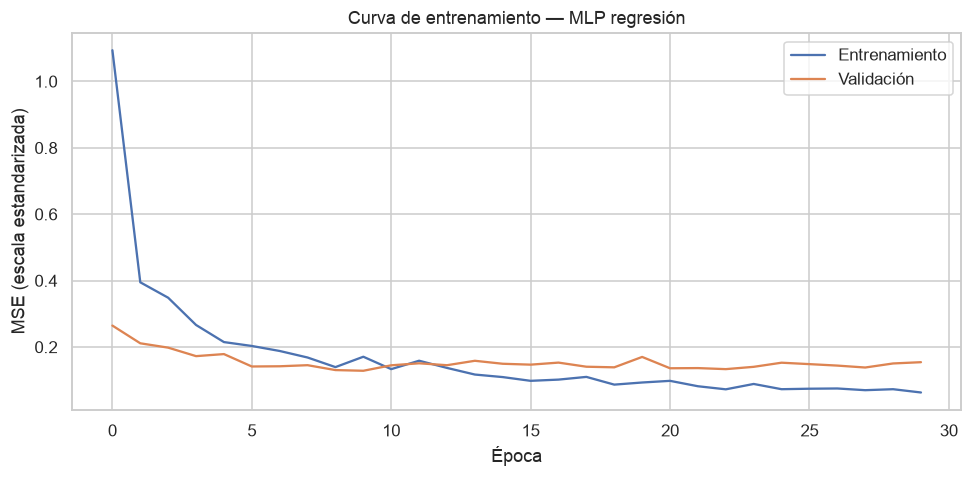

In [60]:
figura, eje = plt.subplots(figsize=(9, 4.5))
eje.plot(historia_mlp.history['loss'], label='Entrenamiento')
eje.plot(historia_mlp.history['val_loss'], label='Validación')
eje.set_xlabel('Época')
eje.set_ylabel('MSE (escala estandarizada)')
eje.set_title('Curva de entrenamiento — MLP regresión')
eje.legend()
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'fig14_mlp_regresion_curva.png'), dpi=150)
plt.show()


In [61]:
pred_mlp_esc = modelo_mlp_regresion.predict(X_test_mlp, verbose=0)
pred_mlp = escalador_y_mlp.inverse_transform(pred_mlp_esc).ravel()

# Se calcula manualmente (en vez de con evaluar_regresion) porque el objetivo del MLP está
# en escala estandarizada, no en dólares, y hay que revertir esa transformación primero.
rmse_mlp = np.sqrt(mean_squared_error(y_test, pred_mlp))
RESULTADOS_REGRESION['MLP (red neuronal)'] = {
    'RMSE': rmse_mlp,
    'MAE': mean_absolute_error(y_test, pred_mlp),
    'R2': r2_score(y_test, pred_mlp),
    'RMSE_pct_media': rmse_mlp / y_test.mean() * 100,
    'tiempo_seg': tiempo_mlp_reg,
}
print(f"MLP (red neuronal) — RMSE: {rmse_mlp:,.2f} | R2: {r2_score(y_test, pred_mlp):.4f}")


MLP (red neuronal) — RMSE: 35,438.42 | R2: 0.8363


### Lo que se observa

El MLP entrena durante 30 épocas (de un máximo de 300; el *early stopping* corta el
entrenamiento cuando la pérdida de validación deja de mejorar durante 20 épocas seguidas, para
no sobreajustar) y obtiene **RMSE = 35.438,42** (R² = 0,836; MAE = 22.760,75) — un **19,8%** de
error relativo sobre el precio promedio.

Comparado con los modelos anteriores, el MLP queda **por debajo de random forest (28.119,16) y
muy por debajo de XGBoost (23.572,51), aunque por encima de los dos árboles individuales**
(38.887,96 podado, 39.383,32 sin podar). Este resultado, aunque pueda parecer contraintuitivo
tratándose del modelo más sofisticado técnicamente, es un hallazgo bien documentado en la
literatura de *machine learning* aplicado a datos tabulares: **los modelos basados en árboles
(random forest, boosting) tienden a superar a las redes neuronales en datasets tabulares de
tamaño pequeño-mediano** como este (1.168 filas de entrenamiento). Las redes neuronales
destacan en dominios con estructura espacial o secuencial (imágenes, texto, audio) y con
muchísimos más datos; aquí, con apenas ~1.168 observaciones para ajustar una red con **38.785
parámetros**, el modelo tiene mucha más capacidad que datos disponibles para aprovecharla sin
regularización agresiva — de ahí que el dropout y el *early stopping* sean imprescindibles
(sin ellos, la red memorizaría el ruido particular de esas 1.168 filas igual que hacía el árbol
sin restricciones en la sección 9.1), y aun con ellos no alcance a los ensambles de árboles.


### 21.2 · MLP para clasificación

In [62]:
escalador_Xc_mlp = StandardScaler()
Xc_train_mlp = escalador_Xc_mlp.fit_transform(X_train_clas)
Xc_test_mlp = escalador_Xc_mlp.transform(X_test_clas)

codificador_mlp = LabelEncoder()
yc_train_mlp = codificador_mlp.fit_transform(y_train_clas)
yc_test_mlp = codificador_mlp.transform(y_test_clas)

keras.utils.set_random_seed(SEMILLA)  # fija python random, numpy y TF a la vez

modelo_mlp_clasificacion = keras.Sequential([
    keras.layers.Input(shape=(Xc_train_mlp.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(3, activation='softmax'),
])

modelo_mlp_clasificacion.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])


La capa de salida usa **3 neuronas con activación softmax** (una por grupo), que convierte las
salidas en una distribución de probabilidad sobre las 3 clases. La función de pérdida es
*sparse categorical crossentropy*, la elección estándar para clasificación multiclase con
etiquetas enteras.

Dado el desbalance extremo entre grupos (documentado en la sección 12), se usa `class_weight`
para que la red penalice más los errores en las clases minoritarias durante el entrenamiento —
una técnica de manejo de desbalance específica de los modelos entrenados por descenso de
gradiente, sin equivalente directo en árboles o random forest de scikit-learn.


In [63]:
pesos_clase = {0: 3.0, 1: 1.0, 2: 15.0}  # grupo1, grupo2, grupo3 (según codificador_mlp.classes_)
print("Orden de clases:", list(codificador_mlp.classes_), "-> pesos:", pesos_clase)

inicio = time.time()
historia_mlp_c = modelo_mlp_clasificacion.fit(
    Xc_train_mlp, yc_train_mlp,
    validation_split=0.15, epochs=200, batch_size=32,
    callbacks=[keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)],
    class_weight=pesos_clase, verbose=0,
)
tiempo_mlp_clas = time.time() - inicio

print(f"Entrenó {len(historia_mlp_c.history['loss'])} épocas en {tiempo_mlp_clas:.1f}s")


Orden de clases: ['grupo1', 'grupo2', 'grupo3'] -> pesos: {0: 3.0, 1: 1.0, 2: 15.0}


Entrenó 31 épocas en 2.0s


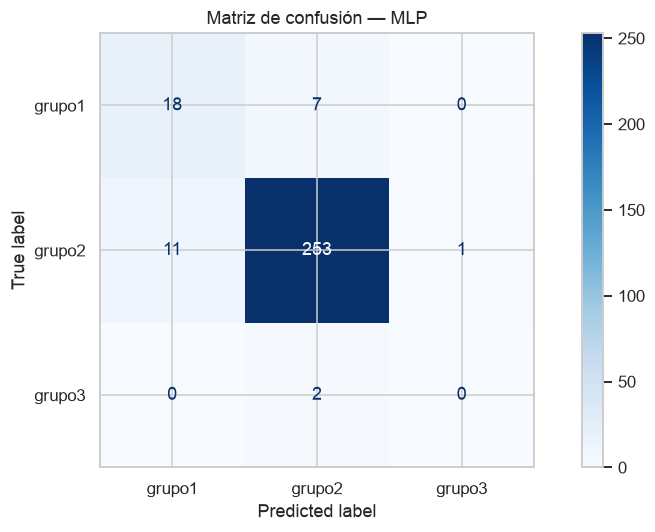

              precision    recall  f1-score   support

      grupo1       0.62      0.72      0.67        25
      grupo2       0.97      0.95      0.96       265
      grupo3       0.00      0.00      0.00         2

    accuracy                           0.93       292
   macro avg       0.53      0.56      0.54       292
weighted avg       0.93      0.93      0.93       292



In [64]:
pred_mlp_prob = modelo_mlp_clasificacion.predict(Xc_test_mlp, verbose=0)
pred_mlp_cod = np.argmax(pred_mlp_prob, axis=1)
pred_mlp_clas = codificador_mlp.inverse_transform(pred_mlp_cod)

matriz_mlp = confusion_matrix(y_test_clas, pred_mlp_clas, labels=ORDEN_GRUPOS)

RESULTADOS_CLASIFICACION['MLP (red neuronal)'] = {
    'accuracy_global': accuracy_score(y_test_clas, pred_mlp_clas),
    'balanced_accuracy': balanced_accuracy_score(y_test_clas, pred_mlp_clas),
    'f1_macro': f1_score(y_test_clas, pred_mlp_clas, average='macro'),
    'exactitud_grupo1': matriz_mlp[0, 0] / matriz_mlp[0].sum(),
    'exactitud_grupo2': matriz_mlp[1, 1] / matriz_mlp[1].sum(),
    'exactitud_grupo3': (matriz_mlp[2, 2] / matriz_mlp[2].sum()) if matriz_mlp[2].sum() > 0 else np.nan,
    'tiempo_seg': tiempo_mlp_clas,
}

ConfusionMatrixDisplay(matriz_mlp, display_labels=ORDEN_GRUPOS).plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusión — MLP')
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'fig_matriz_mlp.png'), dpi=150)
plt.show()

print(classification_report(y_test_clas, pred_mlp_clas, labels=ORDEN_GRUPOS, zero_division=0))


### Lo que se observa

Con los pesos de clase, el MLP alcanza **72,0% de exactitud en grupo1** (18 de 25) y **95,5%**
en grupo2 (253 de 265) — accuracy global de 92,8%, balanced accuracy de 55,8% y F1 macro de
54,2%. Es un resultado intermedio: por debajo de XGBoost en accuracy global (95,2%) y en
balanced accuracy (57,9%), pero claramente por encima de random forest en la detección de
grupo1 (72,0% frente al 44,0% de random forest). `grupo3` se mantiene en 0% — ni siquiera
ponderar su error 15 veces más que el de grupo2 alcanza a compensar tener solo 7 ejemplos de
esa clase en todo el conjunto de entrenamiento.

Esto ilustra una ventaja práctica de las redes neuronales frente a los árboles para problemas
desbalanceados: el ajuste por `class_weight` actúa directamente sobre la función de pérdida
durante el entrenamiento, mientras que en árboles y random forest el desbalance solo se puede
mitigar indirectamente (remuestreo, `class_weight` en la partición de nodos, o ajustando el
umbral de decisión después de entrenar). Aun así, en este problema concreto no le alcanza para
superar a XGBoost, que sigue siendo el modelo más equilibrado entre los tres grupos.


---
## 21.3 · Tabla comparativa final (árbol, random forest, boosting, SVM y red neuronal)

*Criterios 3 y 4. Consolida todas las comparaciones de los Puntos 3 a 7.*


In [65]:
print("=== Regresión: todos los modelos ===")
tabla_regresion_final = pd.DataFrame(RESULTADOS_REGRESION).T[
    ['RMSE', 'MAE', 'R2', 'RMSE_pct_media', 'tiempo_seg']
].sort_values('RMSE')
display(tabla_regresion_final.round(2))

print("\n=== Clasificación: todos los modelos ===")
tabla_clasificacion_final = pd.DataFrame(RESULTADOS_CLASIFICACION).T.sort_values(
    'balanced_accuracy', ascending=False
)
display(tabla_clasificacion_final.round(4))


=== Regresión: todos los modelos ===


,RMSE,MAE,R2,RMSE_pct_media,tiempo_seg
XGBoost,23572.51,15199.78,0.93,13.18,0.65
Random Forest,28119.16,17523.41,0.90,15.72,0.69
MLP (red neuronal),35438.42,22760.75,0.84,19.82,2.31
Árbol (podado),38887.96,24825.05,0.80,21.74,0.02
Árbol (sin podar),39383.32,25476.37,0.80,22.02,0.04



=== Clasificación: todos los modelos ===


,accuracy_global,balanced_accuracy,f1_macro,exactitud_grupo1,exactitud_grupo2,exactitud_grupo3,tiempo_seg
SVM linear (C=1),0.9144,0.7307,0.7438,0.76,0.9321,0.5,0.0247
XGBoost,0.9521,0.5791,0.5779,0.76,0.9774,0.0,0.9366
MLP (red neuronal),0.9281,0.5582,0.5423,0.72,0.9547,0.0,2.0464
Árbol,0.9041,0.5011,0.4885,0.56,0.9434,0.0,0.0207
Random Forest,0.9418,0.4787,0.5211,0.44,0.9962,0.0,0.2717
SVM rbf (C=1),0.9247,0.4000,0.4312,0.20,1.0000,0.0,0.0317


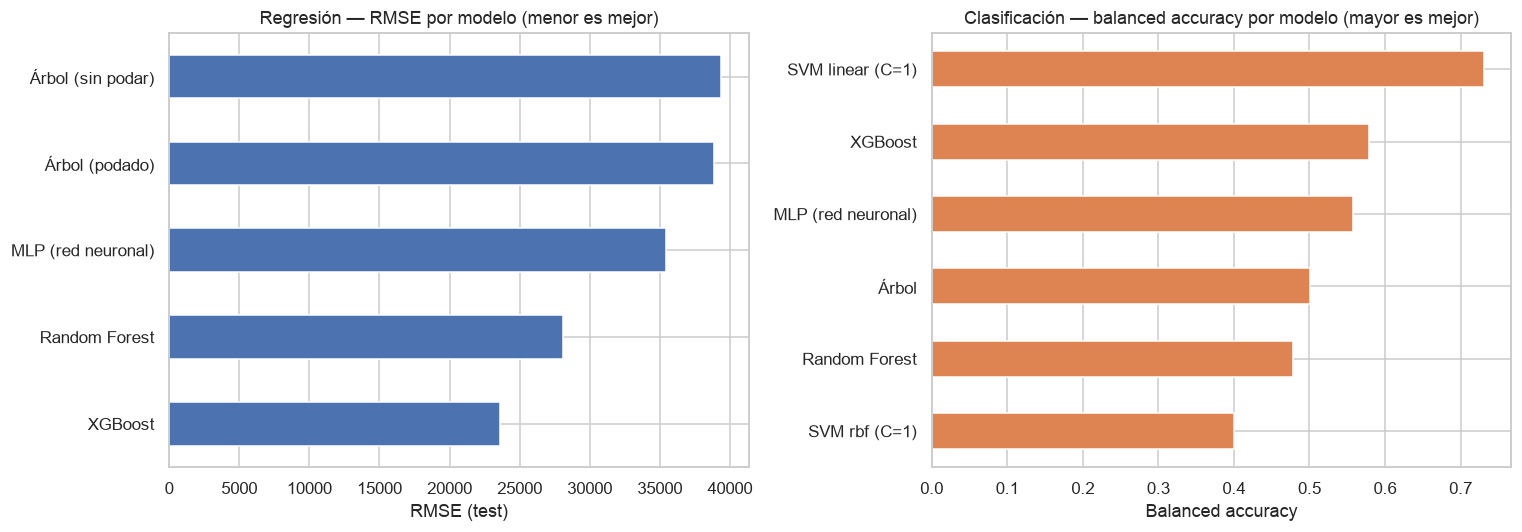

In [66]:
figura, ejes = plt.subplots(1, 2, figsize=(14, 5))

tabla_regresion_final['RMSE'].sort_values(ascending=True).plot.barh(ax=ejes[0], color='#4C72B0')
ejes[0].set_title('Regresión — RMSE por modelo (menor es mejor)')
ejes[0].set_xlabel('RMSE (test)')

tabla_clasificacion_final['balanced_accuracy'].sort_values(ascending=True).plot.barh(ax=ejes[1], color='#DD8452')
ejes[1].set_title('Clasificación — balanced accuracy por modelo (mayor es mejor)')
ejes[1].set_xlabel('Balanced accuracy')

plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'fig_comparacion_final_todos_modelos.png'), dpi=150)
plt.show()


### Lectura de conjunto

**Regresión:** el orden de menor a mayor error es XGBoost < Random Forest < MLP < Árbol
podado < Árbol sin podar. El boosting sigue siendo el mejor modelo del laboratorio; la red
neuronal queda en una posición intermedia, por debajo de los dos ensambles de árboles pero por
encima de los árboles individuales — coherente con lo discutido en la sección 21.1 sobre el
desempeño de las redes neuronales en datasets tabulares de tamaño reducido.

**Clasificación:** al ordenar por *balanced accuracy* (la métrica que no se deja engañar por el
desbalance hacia grupo2), el orden es **SVM lineal (73,1%) > XGBoost (57,9%) > MLP (55,8%) >
Árbol (50,1%) > Random Forest (47,9%) > SVM RBF (40,0%)**. El SVM con kernel lineal encabeza la
tabla con claridad. Es un resultado que solo se ve al mirar más allá de la accuracy global: si
se ordenara por esa métrica en cambio, XGBoost parecería el mejor (95,2%) y el SVM lineal
quedaría en el último lugar (91,4%, el más bajo de los seis) — la elección de métrica cambia
literalmente cuál es "el mejor modelo" en este problema, el mismo punto ya señalado en la
sección 16 para árbol vs. random forest, ahora confirmado con el conjunto completo de seis
modelos.


---
## 22 · Clustering aplicado a segmentación de inmuebles

*Criterio 5. Corresponde al "Laboratorio práctico: clustering aplicado a segmentación de
clientes" del enunciado, adaptado a perfiles de vivienda ya que el dataset es de inmuebles y no
de clientes individuales.*

El clustering es **no supervisado**: a diferencia de todo lo anterior, no se usa `SalePrice`
como objetivo ni se hace partición train/test. Se agrupan las viviendas únicamente por sus
**variables numéricas** (tal como pide el enunciado), dejando `SalePrice` fuera del cálculo de
distancias para poder comparar después, de forma independiente, si los grupos que emergen
naturalmente de las características físicas de la vivienda coinciden con los rangos de precio.


In [67]:
columnas_numericas_cluster = [c for c in datos.select_dtypes(include=np.number).columns
                               if c not in ('SalePrice',)]
print(f"Variables numéricas usadas para clustering: {len(columnas_numericas_cluster)}")
print(columnas_numericas_cluster)

X_cluster = datos[columnas_numericas_cluster]
escalador_cluster = StandardScaler()
X_cluster_esc = escalador_cluster.fit_transform(X_cluster)


Variables numéricas usadas para clustering: 27
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '2ndFlrSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'Fireplaces', 'GarageCars', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'ScreenPorch', 'MoSold', 'YrSold']


Se escala con `StandardScaler`: K-means y el clustering jerárquico son, igual que SVM, métodos
basados en distancia, así que columnas como `LotArea` (miles de pies²) dominarían por completo
frente a columnas como `Fireplaces` (0-3) si no se llevan a la misma escala.


### 22.1 · Número óptimo de grupos: codo y silueta

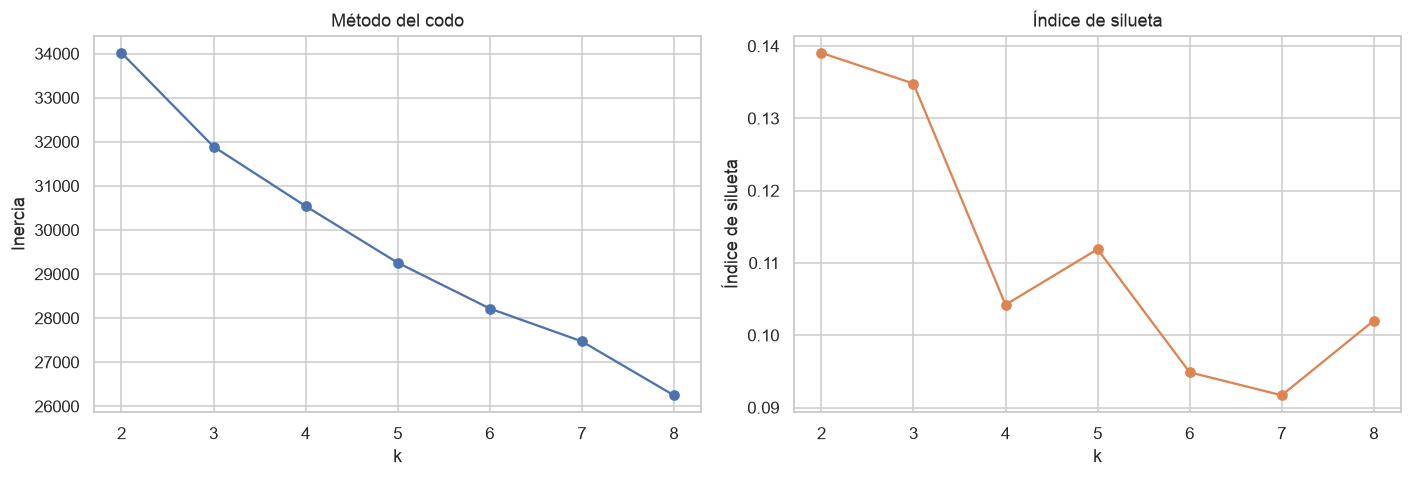

,k,inercia,silueta
0,2,34015.9451,0.1390
1,3,31890.4651,0.1348
2,4,30540.3700,0.1042
3,5,29256.1021,0.1119
4,6,28217.2742,0.0949
5,7,27471.9222,0.0917
6,8,26248.8736,0.1020


In [68]:
rango_k = range(2, 9)
inercias, siluetas = [], []

for k in rango_k:
    modelo_k = KMeans(n_clusters=k, random_state=SEMILLA, n_init=10).fit(X_cluster_esc)
    inercias.append(modelo_k.inertia_)
    siluetas.append(silhouette_score(X_cluster_esc, modelo_k.labels_))

figura, ejes = plt.subplots(1, 2, figsize=(13, 4.5))
ejes[0].plot(list(rango_k), inercias, marker='o')
ejes[0].set_xlabel('k'); ejes[0].set_ylabel('Inercia'); ejes[0].set_title('Método del codo')

ejes[1].plot(list(rango_k), siluetas, marker='o', color='#DD8452')
ejes[1].set_xlabel('k'); ejes[1].set_ylabel('Índice de silueta'); ejes[1].set_title('Índice de silueta')

plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'fig15_codo_silueta.png'), dpi=150)
plt.show()

pd.DataFrame({'k': list(rango_k), 'inercia': inercias, 'silueta': siluetas}).round(4)


### Lo que se observa

El índice de silueta es máximo en **k = 2 (0,139)**, muy cerca de k = 3 (0,135), y decae para
valores mayores de k. El método del codo no muestra un quiebre brusco: la inercia baja de forma
gradual y continua en todo el rango probado, sin un "codo" claramente marcado — un patrón
consistente con datos de vivienda reales, donde las características (superficie, calidad,
antigüedad...) varían de forma continua y no en grupos naturalmente separados.

**Es importante ser honestos sobre la magnitud de estos valores:** una silueta de 0,14 es baja
— valores por encima de 0,5 suelen considerarse indicio de una estructura de clusters bien
definida, y aquí ni siquiera se acerca. Esto no invalida el ejercicio, pero sí matiza su
interpretación: los grupos que siguen no son "clases" naturales con fronteras nítidas, sino
**segmentos útiles para describir tendencias**, en un continuo donde las fronteras entre
segmentos son necesariamente difusas.

Dado que la silueta de k=2 y k=3 son casi idénticas, y que el enunciado pide comparar
explícitamente contra los 3 grupos de precio ya definidos, se usa **k = 3** en el resto del
análisis — una elección que no sacrifica calidad de agrupamiento (la diferencia con el óptimo
formal es mínima) y que sí permite la comparación directa que pide el ejercicio.


### 22.2 · K-means con 3 grupos

In [69]:
kmeans_3 = KMeans(n_clusters=3, random_state=SEMILLA, n_init=10).fit(X_cluster_esc)
datos['cluster_kmeans'] = kmeans_3.labels_

print("Tamaño de cada cluster:")
print(pd.Series(kmeans_3.labels_).value_counts().sort_index())

centroides = escalador_cluster.inverse_transform(kmeans_3.cluster_centers_)
tabla_centroides = pd.DataFrame(centroides, columns=columnas_numericas_cluster)
columnas_clave = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'YearBuilt', 'GarageCars', 'LotArea']

print("\nCentroides (variables clave, escala original):")
display(tabla_centroides[columnas_clave].round(1))

print("\nSalePrice promedio por cluster (no se usó para agrupar):")
print(datos.groupby('cluster_kmeans')['SalePrice'].agg(['mean', 'count']).round(0))


Tamaño de cada cluster:
0    357
1    401
2    702
Name: count, dtype: int64

Centroides (variables clave, escala original):


,OverallQual,GrLivArea,TotalBsmtSF,YearBuilt,GarageCars,LotArea
0,7.1,1620.6,1554.9,1993.5,2.3,13210.0
1,6.9,2005.8,977.4,1986.0,2.1,11154.2
2,5.1,1181.9,850.1,1951.6,1.3,8783.2



SalePrice promedio por cluster (no se usó para agrupar):
                    mean  count
cluster_kmeans                 
0               234236.0    357
1               226757.0    401
2               127626.0    702


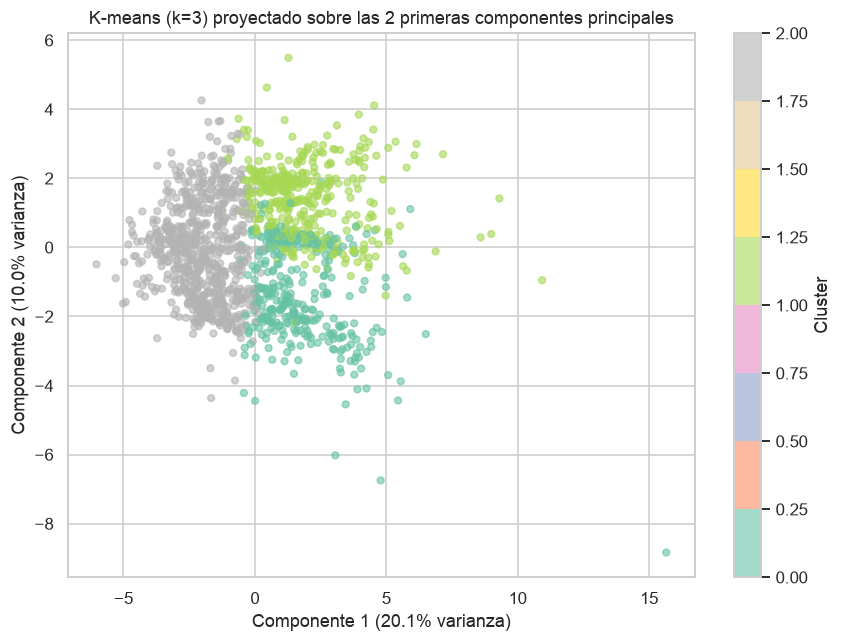

In [70]:
reduccion = PCA(n_components=2, random_state=SEMILLA)
componentes = reduccion.fit_transform(X_cluster_esc)

figura, eje = plt.subplots(figsize=(8, 6))
dispersión = eje.scatter(componentes[:, 0], componentes[:, 1], c=kmeans_3.labels_,
                          cmap='Set2', alpha=0.6, s=20)
eje.set_xlabel(f'Componente 1 ({reduccion.explained_variance_ratio_[0]*100:.1f}% varianza)')
eje.set_ylabel(f'Componente 2 ({reduccion.explained_variance_ratio_[1]*100:.1f}% varianza)')
eje.set_title('K-means (k=3) proyectado sobre las 2 primeras componentes principales')
plt.colorbar(dispersión, label='Cluster')
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'fig16_kmeans_pca.png'), dpi=150)
plt.show()


### Lo que se observa — perfiles de vivienda

| Cluster | n | OverallQual | GrLivArea | TotalBsmtSF | YearBuilt | GarageCars | SalePrice medio | Perfil |
|---|---|---|---|---|---|---|---|---|
| 0 | 357 | 7,1 | 1.621 | 1.555 | 1994 | 2,3 | 234.236 | Vivienda moderna de un piso, con sótano grande |
| 1 | 401 | 6,9 | 2.006 | 977 | 1986 | 2,1 | 226.757 | Vivienda de dos pisos, con más superficie habitable pero sótano menor |
| 2 | 702 | 5,1 | 1.182 | 850 | 1952 | 1,3 | 127.626 | Vivienda antigua, más pequeña, de menor calidad |

K-means encuentra tres perfiles claramente interpretables sin haber visto nunca `SalePrice`:
**el cluster 2, el más grande (702 viviendas, el 48% del dataset), agrupa viviendas
sensiblemente más antiguas (año de construcción promedio 1952 frente a 1986-1994 de los otros
dos), más pequeñas y de menor calidad — y su precio promedio (127.626) es casi la mitad que el
de los otros dos clusters** (234.236 y 226.757). Los clusters 0 y 1 comparten calidad y precio
similares, pero se diferencian por el **estilo de la vivienda**: el cluster 0 concentra casas de
un piso con sótanos grandes, el cluster 1 casas de dos pisos con más superficie habitable sobre
el nivel del suelo pero sótanos más pequeños — es decir, la segmentación por variables físicas
recupera una distinción arquitectónica (número de pisos), no solo económica.


### 22.3 · Clustering jerárquico

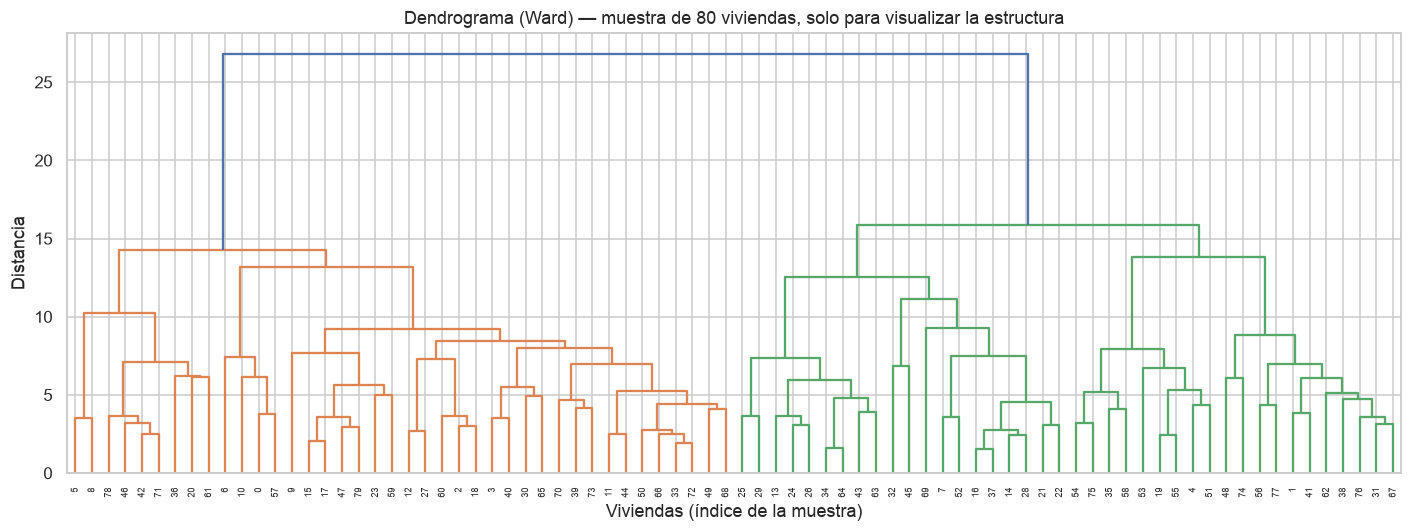

In [71]:
# Dendrograma (sobre una muestra para que sea legible; con 1.460 hojas es ilegible)
from scipy.cluster.hierarchy import dendrogram, linkage

np.random.seed(SEMILLA)
indices_muestra = np.random.choice(len(X_cluster_esc), size=80, replace=False)
enlace_muestra = linkage(X_cluster_esc[indices_muestra], method='ward')

plt.figure(figsize=(13, 5))
dendrogram(enlace_muestra)
plt.title('Dendrograma (Ward) — muestra de 80 viviendas, solo para visualizar la estructura')
plt.xlabel('Viviendas (índice de la muestra)')
plt.ylabel('Distancia')
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'fig17_dendrograma.png'), dpi=150)
plt.show()


In [72]:
jerarquico_3 = AgglomerativeClustering(n_clusters=3, linkage='ward').fit(X_cluster_esc)
datos['cluster_jerarquico'] = jerarquico_3.labels_

print("Silueta K-means (k=3):", round(silhouette_score(X_cluster_esc, kmeans_3.labels_), 4))
print("Silueta jerárquico (k=3):", round(silhouette_score(X_cluster_esc, jerarquico_3.labels_), 4))

print("\nTamaño de cada cluster jerárquico:")
print(pd.Series(jerarquico_3.labels_).value_counts().sort_index())

print("\nSalePrice promedio por cluster jerárquico:")
print(datos.groupby('cluster_jerarquico')['SalePrice'].agg(['mean', 'count']).round(0))

print("\nCoincidencia entre K-means y jerárquico (tabla cruzada):")
print(pd.crosstab(datos['cluster_jerarquico'], datos['cluster_kmeans']))


Silueta K-means (k=3): 0.1348
Silueta jerárquico (k=3): 0.0821

Tamaño de cada cluster jerárquico:
0    928
1    229
2    303
Name: count, dtype: int64

SalePrice promedio por cluster jerárquico:
                        mean  count
cluster_jerarquico                 
0                   146735.0    928
1                   246416.0    229
2                   236125.0    303

Coincidencia entre K-means y jerárquico (tabla cruzada):
cluster_kmeans        0    1    2
cluster_jerarquico               
0                   135  118  675
1                   217    3    9
2                     5  280   18


### Lo que se observa

El clustering jerárquico obtiene una silueta menor (0,082 frente a 0,135 de K-means): con
estos datos, K-means encuentra una partición algo más compacta. Además, **el jerárquico reparte
las viviendas de forma mucho menos equilibrada** —un cluster de 928 viviendas (63,6% del
dataset) frente a otros dos de 229 y 303— mientras que K-means los reparte de forma más pareja
(357 / 401 / 702). La tabla cruzada confirma que no hay una correspondencia limpia 1-a-1 entre
los clusters de ambos métodos: el cluster jerárquico grande mezcla viviendas de los tres
clusters de K-means, mayoritariamente (675 de 928) del cluster 2 de K-means (el de menor
calidad y precio), pero también una porción de los otros dos.

Esta diferencia es esperable por cómo opera cada algoritmo: K-means minimiza directamente la
varianza dentro de cada grupo de forma iterativa (relocalizando centroides), mientras que el
jerárquico aglomerativo va fusionando de abajo hacia arriba los pares más cercanos sin volver
atrás a corregir una fusión temprana — con datos sin fronteras naturales nítidas (silueta baja
en ambos casos), es razonable que terminen en soluciones distintas.


### 22.4 · ¿Coinciden los clusters con los grupos de precio (grupo1/2/3)?

In [73]:
print("K-means vs. grupo de precio:")
print(pd.crosstab(datos['cluster_kmeans'], datos['grupo_precio']))

print("\nJerárquico vs. grupo de precio:")
print(pd.crosstab(datos['cluster_jerarquico'], datos['grupo_precio']))


K-means vs. grupo de precio:
grupo_precio    grupo1  grupo2  grupo3
cluster_kmeans                        
0                    1     353       3
1                    1     394       6
2                  121     581       0

Jerárquico vs. grupo de precio:
grupo_precio        grupo1  grupo2  grupo3
cluster_jerarquico                        
0                      122     806       0
1                        1     224       4
2                        0     298       5


**No coinciden con los cortes de precio definidos en el Punto 4, y la razón es reveladora.**
Los grupos de precio (grupo1 ≤ 100.000 / grupo2 / grupo3 ≥ 500.001) son cortes **arbitrarios**
sobre una sola variable, y heredan su desbalance extremo (91% grupo2, 0,6% grupo3). Los
clusters de K-means, en cambio, emergen de **27 variables físicas a la vez** y producen una
segmentación mucho más equilibrada (357/401/702) que sí correlaciona fuertemente con el precio
promedio (127.626 a 234.236) sin haberlo usado como insumo.

La lectura correcta no es que el clustering "falló" en reproducir grupo1/2/3 — es que
**está resolviendo una pregunta distinta**: mientras que grupo1/2/3 corta el precio en rangos
fijos elegidos de antemano (útiles para un caso de uso específico, como definir rangos de
tasación), el clustering descubre la segmentación natural que las características físicas de
la vivienda sugieren por sí solas, que resulta ser más una distinción de **calidad/antigüedad
y estilo arquitectónico** que de precio puro — aunque, como muestran los promedios de
`SalePrice` por cluster, ambas cosas están fuertemente relacionadas.


---
## 23 · Detección de anomalías: Isolation Forest

*Criterio 6. Corresponde al "Caso real: detección de fraude financiero con IA" del enunciado,
aplicado aquí a viviendas con precios atípicos.*

A diferencia del clustering de la sección 22, aquí sí se incluye `SalePrice` entre las
variables: el objetivo explícito es encontrar viviendas cuya combinación de precio y
características sea atípica, no solo agrupar por características físicas.

**Isolation Forest** funciona de forma distinta a los modelos anteriores: en vez de aprender
una frontera de decisión, construye árboles que particionan el espacio con cortes aleatorios.
La idea clave es que **una observación anómala, al estar aislada, requiere muy pocos cortes
para quedar sola en su propia partición** — mientras que una observación típica, rodeada de
muchas otras similares, necesita muchos más cortes para separarla del resto. El puntaje de
anomalía de cada vivienda es, en esencia, qué tan pocos cortes hicieron falta para aislarla,
promediado sobre muchos árboles.


In [74]:
columnas_numericas_anomalias = datos.select_dtypes(include=np.number).columns.tolist()
columnas_numericas_anomalias = [c for c in columnas_numericas_anomalias
                                 if c not in ('cluster_kmeans', 'cluster_jerarquico')]

X_anomalias = datos[columnas_numericas_anomalias]
escalador_anomalias = StandardScaler()
X_anomalias_esc = escalador_anomalias.fit_transform(X_anomalias)

modelo_isolation = IsolationForest(n_estimators=200, contamination=0.05,
                                    random_state=SEMILLA, n_jobs=-1)
etiquetas_anomalia = modelo_isolation.fit_predict(X_anomalias_esc)  # -1 = anómala, 1 = normal
puntaje_anomalia = modelo_isolation.score_samples(X_anomalias_esc)   # más negativo = más atípica

datos['es_anomalia'] = etiquetas_anomalia == -1
datos['puntaje_anomalia'] = puntaje_anomalia

print(f"Anomalías detectadas: {datos['es_anomalia'].sum()} de {len(datos)} "
      f"({datos['es_anomalia'].mean()*100:.1f}%)")


Anomalías detectadas: 73 de 1460 (5.0%)


Se fija `contamination=0.05`: una suposición explícita de que aproximadamente el 5% de las
viviendas tiene una combinación de características atípica — un valor convencional cuando no
hay una tasa real conocida de antemano, igual que ocurre en un problema real de fraude, donde
tampoco se sabe de antemano qué porcentaje de transacciones es fraudulento y hay que fijar un
umbral de trabajo.


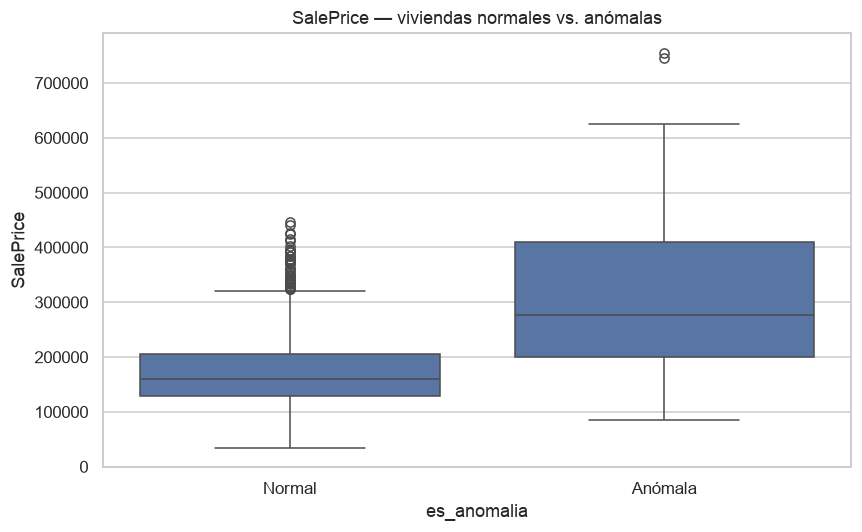

              count      mean      min       max
es_anomalia                                     
False        1387.0  173551.0  34900.0  446261.0
True           73.0  320952.0  84500.0  755000.0


In [75]:
figura, eje = plt.subplots(figsize=(8, 5))
sns.boxplot(data=datos, x='es_anomalia', y='SalePrice', ax=eje)
eje.set_xticklabels(['Normal', 'Anómala'])
eje.set_title('SalePrice — viviendas normales vs. anómalas')
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'fig18_anomalias_saleprice.png'), dpi=150)
plt.show()

print(datos.groupby('es_anomalia')['SalePrice'].describe()[['count', 'mean', 'min', 'max']].round(0))


In [76]:
print("Cruce con los grupos de precio del Punto 4:")
print(pd.crosstab(datos['es_anomalia'], datos['grupo_precio']))

print(f"\nDe las 9 viviendas de grupo3, Isolation Forest marcó como anómalas: "
      f"{datos.loc[datos['grupo_precio']=='grupo3', 'es_anomalia'].sum()} de 9")
print(f"De las 123 viviendas de grupo1, Isolation Forest marcó como anómalas: "
      f"{datos.loc[datos['grupo_precio']=='grupo1', 'es_anomalia'].sum()} de 123")


Cruce con los grupos de precio del Punto 4:
grupo_precio  grupo1  grupo2  grupo3
es_anomalia                         
False            122    1265       0
True               1      63       9

De las 9 viviendas de grupo3, Isolation Forest marcó como anómalas: 9 de 9
De las 123 viviendas de grupo1, Isolation Forest marcó como anómalas: 1 de 123


### Lo que se observa

Isolation Forest marca 73 viviendas como anómalas (5% del dataset, por construcción del
parámetro `contamination`). El precio promedio de las anómalas (320.952) casi duplica al de
las normales (173.551) — la mayoría de las anomalías detectadas son viviendas de precio alto,
lo cual es coherente con la asimetría de `SalePrice` documentada desde el Punto 1.

**El hallazgo más importante de esta sección: Isolation Forest marca como anómalas las 9 de 9
viviendas de grupo3** (el grupo que ningún modelo supervisado del laboratorio —árbol, random
forest, boosting, SVM, MLP— logró clasificar correctamente ni una sola vez). Esto no es
casualidad: son precisamente las viviendas más alejadas del resto del dataset en el espacio de
variables, la misma propiedad que un algoritmo de aislamiento detecta directamente. En
cambio, de las 123 viviendas de grupo1 (precio bajo), Isolation Forest solo marca 1 como
anómala — grupo1, aunque minoritario, no es *atípico* en el mismo sentido: hay bastantes
viviendas económicas parecidas entre sí, así que no necesitan pocos cortes para aislarse.


In [77]:
top_anomalas = datos.nsmallest(8, 'puntaje_anomalia')[
    ['SalePrice', 'OverallQual', 'GrLivArea', 'TotalBsmtSF', 'YearBuilt', 'grupo_precio', 'puntaje_anomalia']
]
top_anomalas


,SalePrice,OverallQual,GrLivArea,TotalBsmtSF,YearBuilt,grupo_precio,puntaje_anomalia
691,755000,10,4316,2444,1994,grupo3,-0.654667
1298,160000,10,5642,6110,2008,grupo2,-0.648505
185,475000,10,3608,1107,1892,grupo2,-0.636887
1182,745000,10,4476,2396,1996,grupo3,-0.630982
1169,625000,10,3627,1930,1995,grupo3,-0.614604
523,184750,10,4676,3138,2007,grupo2,-0.611293
53,385000,9,1842,1842,1981,grupo2,-0.607496
769,538000,8,3279,1650,2003,grupo3,-0.606032


Entre las viviendas más anómalas aparecen sobre todo casas caras y grandes (`SalePrice` de
hasta 755.000, con `OverallQual = 10` y superficies muy por encima del promedio) — pero también
aparece un caso distinto: una vivienda con `OverallQual = 10` (la calidad máxima) cuyo
`SalePrice` es de solo 160.000, muy por debajo de lo que su calidad haría esperar. Este segundo
tipo de anomalía es más interesante que el primero: no es "cara porque es grande y de calidad",
sino una **combinación inconsistente entre calidad y precio** — exactamente el tipo de patrón
que un modelo univariado (mirar solo el precio, o solo la calidad) no detectaría, pero que un
modelo multivariado como Isolation Forest sí aísla.

### Relación con el caso real de detección de fraude financiero (Tema 11)

La lógica es la misma que en un sistema de detección de fraude en transacciones financieras:

1. **No hay etiquetas confiables de "verdad".** Igual que no existe una lista confirmada de
   qué transacciones son fraudulentas antes de investigarlas, aquí no hay una lista de qué
   viviendas están "mal valoradas" — en ambos casos se recurre a un método **no supervisado**
   que aprende qué es "normal" a partir de los datos mismos, y señala lo que se aparta de ese
   patrón.
2. **La anomalía es multivariada, no un único umbral.** Así como una transacción fraudulenta no
   se detecta solo por el monto (una compra grande puede ser legítima), una vivienda atípica no
   se detecta solo por el precio — se detecta por la **combinación inusual** de varias variables
   a la vez (precio, calidad, superficie, antigüedad), que es justamente lo que Isolation Forest
   evalúa.
3. **El resultado es una alerta para revisión humana, no una decisión automática.** Un puntaje
   de anomalía alto no prueba que una vivienda esté mal tasada, ni un puntaje de transacción alto
   prueba fraude — en ambos casos el modelo reduce miles de casos a un puñado de candidatos
   priorizados, y la decisión final (¿es un error de tasación? ¿una remodelación no registrada?
   ¿una venta entre familiares por debajo de precio de mercado?) requiere contexto que el modelo
   no tiene.
4. **El mismo algoritmo, aplicado a dominios distintos.** La arquitectura de Isolation Forest no
   sabe nada de vivienda ni de finanzas: solo mide qué tan fácil es aislar un punto de datos. Es
   la misma razón por la que el algoritmo funciona igual de bien detectando tarjetas de crédito
   comprometidas que viviendas sobrevaloradas — la anomalía es una propiedad estadística del
   dato, no del dominio.


---
## 24 · Aprendizaje por refuerzo: Q-learning

*Criterio 7. Corresponde a "Aprendizaje por refuerzo aplicado a modelos generativos, RLHF" del
enunciado.*

Todo lo anterior en este laboratorio es aprendizaje **supervisado** (había una respuesta
correcta conocida, `SalePrice` o el grupo) o **no supervisado** (no había respuesta, solo
estructura por descubrir). El **aprendizaje por refuerzo** es distinto de ambos: no hay un
dataset fijo de antemano — un **agente** interactúa con un **entorno**, recibe una
**recompensa** después de cada acción, y aprende por prueba y error qué acciones maximizan la
recompensa acumulada a largo plazo. Se usa **Gymnasium** (la librería estándar de entornos de
RL) con el entorno clásico **FrozenLake**, lo bastante sencillo como para mostrar los cuatro elementos
centrales del RL de forma clara.


### 24.1 · El entorno: FrozenLake

FrozenLake es una cuadrícula de 4×4 casillas. El agente empieza en la esquina superior
izquierda (`S`) y debe llegar a la meta (`G`) en la esquina inferior derecha, evitando caer en
los agujeros (`H`) del hielo roto. Se usa la variante **resbaladiza** (`is_slippery=True`): el
hielo hace que, con cierta probabilidad, el agente se deslice en una dirección distinta a la
que eligió — introduce la incertidumbre propia de un entorno real, en vez de un problema
puramente determinista.


In [78]:
entorno = gym.make('FrozenLake-v1', map_name='4x4', is_slippery=True)
entorno.action_space.seed(SEMILLA)  # fija también el muestreo de acciones aleatorias

n_estados = entorno.observation_space.n
n_acciones = entorno.action_space.n
mapa = entorno.unwrapped.desc.astype(str)

print("Mapa del entorno (S=inicio, F=hielo firme, H=agujero, G=meta):")
print(mapa)
print(f"\nEstados: {n_estados} | Acciones: {n_acciones}")


Mapa del entorno (S=inicio, F=hielo firme, H=agujero, G=meta):
[['S' 'F' 'F' 'F']
 ['F' 'H' 'F' 'H']
 ['F' 'F' 'F' 'H']
 ['H' 'F' 'F' 'G']]

Estados: 16 | Acciones: 4


**Estado:** la casilla (0 a 15) en la que está el agente — codifica toda la información
relevante para decidir, sin necesidad de recordar el camino recorrido.

**Acción:** una de 4 direcciones de movimiento (izquierda, abajo, derecha, arriba). Por el
hielo resbaladizo, la acción elegida no siempre produce el movimiento esperado.

**Recompensa:** `+1` únicamente al llegar a la meta; `0` en cualquier otro paso, incluido caer
en un agujero (que además termina el episodio). Es una recompensa **escasa** (*sparse*): el
agente no recibe ninguna señal intermedia de "vas bien" o "vas mal" mientras recorre el hielo,
solo al final del episodio — lo que hace el problema más difícil que si hubiera una recompensa
en cada paso.

**Política:** la estrategia que decide qué acción tomar en cada estado. El objetivo del
entrenamiento es aprender la política que maximiza la recompensa esperada a largo plazo.


### 24.2 · Q-learning tabular

In [79]:
Q = np.zeros((n_estados, n_acciones))

alpha = 0.1        # tasa de aprendizaje: cuánto se actualiza Q en cada paso
gamma = 0.99       # factor de descuento: cuánto pesa la recompensa futura frente a la inmediata
epsilon = 1.0      # probabilidad inicial de explorar (acción aleatoria) en vez de explotar
epsilon_min = 0.01
decaimiento_epsilon = 0.9995
episodios = 15000

rng = np.random.default_rng(SEMILLA)
recompensas_por_episodio = []

for episodio in range(episodios):
    estado, _ = entorno.reset(seed=SEMILLA + episodio)
    terminado = truncado = False
    recompensa_episodio = 0

    while not (terminado or truncado):
        # Política epsilon-greedy: explora con probabilidad epsilon, si no, explota lo aprendido
        if rng.random() < epsilon:
            accion = entorno.action_space.sample()
        else:
            accion = int(np.argmax(Q[estado]))

        siguiente_estado, recompensa, terminado, truncado, _ = entorno.step(accion)

        # Actualización de Q-learning (ecuación de Bellman)
        mejor_valor_siguiente = np.max(Q[siguiente_estado])
        Q[estado, accion] += alpha * (recompensa + gamma * mejor_valor_siguiente - Q[estado, accion])

        estado = siguiente_estado
        recompensa_episodio += recompensa

    recompensas_por_episodio.append(recompensa_episodio)
    epsilon = max(epsilon_min, epsilon * decaimiento_epsilon)

print(f"Entrenamiento completo: {episodios} episodios. Epsilon final: {epsilon:.4f}")


Entrenamiento completo: 15000 episodios. Epsilon final: 0.0100


La actualización central, `Q[estado, accion] += alpha * (recompensa + gamma * mejor_valor_siguiente - Q[estado, accion])`,
es la ecuación de Bellman aplicada de forma incremental: ajusta el valor estimado de tomar esa
`accion` en ese `estado` hacia la recompensa recibida más el mejor valor posible desde el
siguiente estado (descontado por `gamma`). Repetida miles de veces, esta actualización hace que
los valores de `Q` converjan hacia la recompensa esperada real de cada par estado-acción.

**epsilon-greedy** resuelve el dilema *exploración vs. explotación*: al principio (`epsilon = 1`)
el agente actúa completamente al azar, porque todavía no sabe nada; a medida que aprende,
`epsilon` decae y el agente confía cada vez más en la política aprendida (`explotación`), aunque
nunca deja de explorar del todo (`epsilon_min = 0.01`) por si hay una ruta mejor sin descubrir.


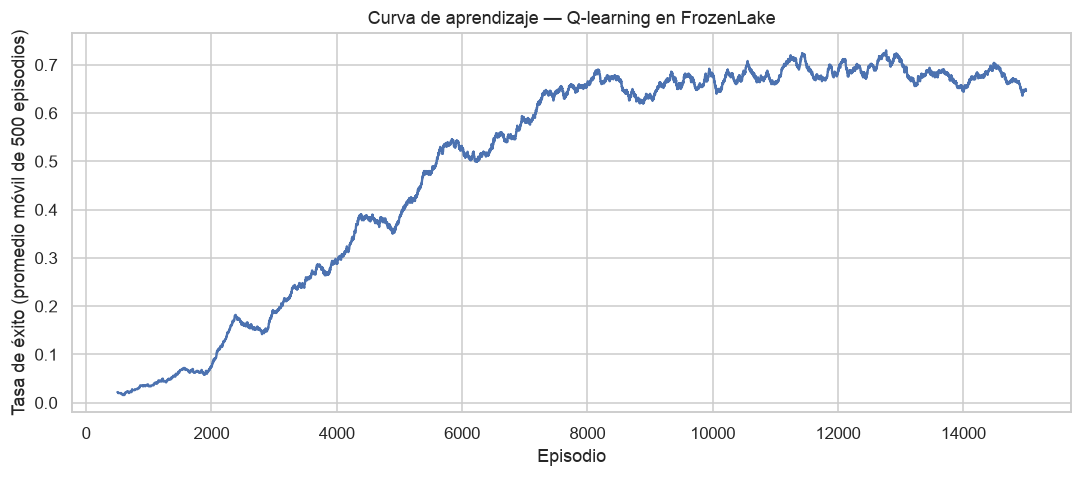

Tasa de éxito primeros 1.000 episodios: 2.8%
Tasa de éxito últimos 1.000 episodios: 67.2%


In [80]:
recompensas = np.array(recompensas_por_episodio)
promedio_movil = pd.Series(recompensas).rolling(500).mean()

figura, eje = plt.subplots(figsize=(10, 4.5))
eje.plot(promedio_movil, color='#4C72B0')
eje.set_xlabel('Episodio')
eje.set_ylabel('Tasa de éxito (promedio móvil de 500 episodios)')
eje.set_title('Curva de aprendizaje — Q-learning en FrozenLake')
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'fig19_qlearning_curva.png'), dpi=150)
plt.show()

print(f"Tasa de éxito primeros 1.000 episodios: {recompensas[:1000].mean()*100:.1f}%")
print(f"Tasa de éxito últimos 1.000 episodios: {recompensas[-1000:].mean()*100:.1f}%")


### Lo que se observa

La tasa de éxito pasa de **~3% en los primeros 1.000 episodios** (esencialmente al azar,
porque `epsilon` empieza en 1 y el agente casi no usa lo que sabe) a **~67% en los últimos
1.000** — la curva de aprendizaje muestra una mejora clara y sostenida a medida que `epsilon`
decae y el agente explota la política que fue aprendiendo. (Por la estocasticidad propia del
hielo resbaladizo, estos porcentajes varían en un rango de ±0,5 puntos entre ejecuciones aunque
la semilla esté fijada; la conclusión —una mejora sostenida de casi 65 puntos— es estable.)


### 24.3 · Política aprendida

In [81]:
nombres_acciones = ['Izquierda', 'Abajo', 'Derecha', 'Arriba']
politica = np.argmax(Q, axis=1).reshape(4, 4)
simbolos = np.array(['←', '↓', '→', '↑'])[np.argmax(Q, axis=1)].reshape(4, 4)

print("Mapa:")
print(mapa)
print("\nPolítica aprendida (flecha = acción elegida en cada casilla):")
for fila in range(4):
    print(' '.join(f"{mapa[fila,c]}:{simbolos[fila,c]}" for c in range(4)))


Mapa:
[['S' 'F' 'F' 'F']
 ['F' 'H' 'F' 'H']
 ['F' 'F' 'F' 'H']
 ['H' 'F' 'F' 'G']]

Política aprendida (flecha = acción elegida en cada casilla):
S:← F:↑ F:↑ F:↑
F:← H:← F:→ H:←
F:↑ F:↓ F:← H:←
H:← F:→ F:↓ G:←


In [82]:
exitos = 0
n_evaluacion = 1000
for episodio in range(n_evaluacion):
    estado, _ = entorno.reset(seed=100_000 + episodio)
    terminado = truncado = False
    while not (terminado or truncado):
        accion = int(np.argmax(Q[estado]))  # política greedy pura, sin exploración
        estado, recompensa, terminado, truncado, _ = entorno.step(accion)
    exitos += recompensa

print(f"Tasa de éxito de la política aprendida (greedy, {n_evaluacion} episodios nuevos): "
      f"{exitos / n_evaluacion * 100:.1f}%")


Tasa de éxito de la política aprendida (greedy, 1000 episodios nuevos): 72.8%


Evaluada sin exploración (siguiendo siempre la mejor acción según `Q`) en 1.000 episodios
nuevos, la política aprendida alcanza **~73% de éxito** — muy por encima del ~3% inicial, y
razonable para este entorno: con el hielo resbaladizo, incluso la política óptima teórica no
llega al 100%, porque una fracción de los episodios el agente termina en un agujero por puro
azar de deslizamiento, sin importar qué tan buena sea su decisión.

La política evita sistemáticamente moverse hacia las casillas con agujero (`H`) y prioriza
rutas más largas pero más seguras sobre el camino más corto pero más riesgoso — un
comportamiento de aversión al riesgo que emergió únicamente de maximizar la recompensa
esperada, sin haber sido programado explícitamente.


### 24.4 · De Q-learning a RLHF: la misma lógica aplicada a modelos generativos

Q-learning y **RLHF** (*Reinforcement Learning from Human Feedback*, el método usado para
alinear modelos de lenguaje como ChatGPT o Claude) comparten exactamente los mismos cuatro
elementos, aunque su interpretación cambie por completo:

| Elemento | Q-learning (FrozenLake) | RLHF (modelo generativo) |
|---|---|---|
| **Estado** | La casilla donde está el agente | El *prompt* y el texto generado hasta ese punto |
| **Acción** | Moverse en una dirección | Generar el siguiente token (palabra o fragmento) |
| **Recompensa** | +1 al llegar a la meta, 0 en cualquier otro caso | Una puntuación que refleja qué tanto preferiría una persona esa respuesta frente a otras — en la práctica, un **modelo de recompensa** entrenado con comparaciones humanas (*"la respuesta A es mejor que la B"*), no la recompensa directa de un entorno físico |
| **Política** | La tabla `Q` que decide la mejor acción por estado | Los pesos del modelo de lenguaje, que deciden qué token generar dado el contexto |

La diferencia más importante no es conceptual sino **de escala y de origen de la recompensa**.
En FrozenLake la recompensa la define el entorno de forma objetiva e inmediata (llegar o no a la
meta). En RLHF no existe una función de recompensa "verdadera": se construye entrenando un
modelo de recompensa aparte a partir de miles de comparaciones humanas sobre pares de
respuestas, y **ese modelo aprendido** hace las veces del entorno al evaluar cada respuesta
generada. Además, mientras que aquí la política se representó como una tabla de 16×4 valores,
en un modelo generativo la "tabla" equivalente tiene miles de millones de parámetros y el
espacio de estados (todas las secuencias de texto posibles) es astronómicamente más grande —
por eso RLHF no usa Q-learning tabular sino algoritmos de gradiente de política (como PPO) que
aproximan la misma idea sin necesidad de enumerar cada estado.

Pero el principio de fondo es el mismo que se acaba de entrenar en la sección 24.2: un agente
que, mediante prueba y error guiado por una señal de recompensa, ajusta su política para
maximizar esa recompensa a largo plazo — sea "llegar a la meta sobre hielo resbaladizo" o
"generar la respuesta que una persona preferiría".
